# Simplified Neuropixel Prediction Notebook
A description and demo notebook to go through creating a 2D CNN + Readout

## 1. Setting up paths and global variables

In [1]:
# To access to neuropixel_predictor
import sys
import os
sys.path.append('../')

# Basic imports
import warnings
import random

# Essential imports
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", category=UserWarning)
# device = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 10

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


ROOT_DIR = '../'
PLOTS_DIR = 'plots'

IMAGE_WIDTH = WIDTH = 36
IMAGE_HEIGHT = HEIGHT = 22

## 2. Setting up data helper methods

In [2]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class SimpleDataset(Dataset):
    def __init__(self, x, y, ids):
        assert len(x) == len(y) == len(ids)
        self.x = x
        self.y = y
        self.ids = ids

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.ids[idx]

In [3]:
from torch.utils.data import DataLoader

# Change this 
TRAINING_DATA_DIR = '/Users/tarek/Documents/UNI/Lab Rotations/Kremkow/Data/Training-SparseNoise-Dark' # Training-SparseNoise-Dark Training-SN-Dark-36-22
BATCH_SIZE = 32

reconstruction_metadata = {}

def load_dataset(date, batch_size=BATCH_SIZE, flip_axis=False):
    # 1. Load the images and responses
    training_images = np.load(os.path.join(TRAINING_DATA_DIR, "training_images_{}.npy".format(date)))
    training_responses = np.load(os.path.join(TRAINING_DATA_DIR, "training_responses_{}.npy".format(date)))
    training_reconstruct = np.load(
        os.path.join(TRAINING_DATA_DIR, "training_reconstruct_{}.npy".format(date)),
        allow_pickle=True).item()
    training_reconstruct_ids = training_reconstruct['ids']
    
    test_images = np.load(os.path.join(TRAINING_DATA_DIR, "test_images_{}.npy".format(date)))
    test_responses = np.load(os.path.join(TRAINING_DATA_DIR, "test_responses_{}.npy".format(date)))
    test_reconstruct = np.load(
        os.path.join(TRAINING_DATA_DIR, "test_reconstruct_{}.npy".format(date)),
        allow_pickle=True).item()
    test_reconstruct_ids = test_reconstruct['ids']

    reconstruction_metadata = test_reconstruct['meta']

    if flip_axis:
        training_images = np.transpose(training_images, (0, 1, 3, 2))
        test_images = np.transpose(test_images, (0, 1, 3, 2))

    # training_images = training_images.reshape(training_images.shape[0], 1, IMAGE_WIDTH, IMAGE_HEIGHT)
    # test_images = test_images.reshape(test_images.shape[0], 1, IMAGE_WIDTH, IMAGE_HEIGHT)
    
    # 2. Convert to tensors and typecast to float
    training_images = torch.from_numpy(training_images).float()
    test_images = torch.from_numpy(test_images).float()
    
    training_responses = torch.from_numpy(training_responses).float()
    test_responses = torch.from_numpy(test_responses).float()
    
    # 3. Zip training and test
    # training_data = list(zip(training_images, training_responses))
    # test_data = list(zip(test_images, test_responses))
    training_data = SimpleDataset(training_images, training_responses, training_reconstruct_ids)
    test_data = SimpleDataset(test_images, test_responses, test_reconstruct_ids)

    # 4. Convert to DataLoader
    train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_dataloader, test_dataloader, training_responses.mean()

# 1. Load data with date
train_dataloader_1, test_dataloader_1, resp_mean_1 = load_dataset("2023-03-15_11-05", flip_axis=False)
train_dataloader_2, test_dataloader_2, resp_mean_2 = load_dataset("2023-03-15_15-23", flip_axis=False)
train_dataloader_3, test_dataloader_3, resp_mean_3 = load_dataset("2022-12-20_15-08", flip_axis=False)

train_dataloaders = {
    "2023-03-15_11-05": train_dataloader_1,
    "2023-03-15_15-23": train_dataloader_2,
    "2022-12-20_15-08": train_dataloader_3,
}

test_dataloaders = {
    "2023-03-15_11-05": test_dataloader_1,
    "2023-03-15_15-23": test_dataloader_2,
    "2022-12-20_15-08": test_dataloader_3,
}

test_reconstruct = np.load(
        os.path.join(TRAINING_DATA_DIR, "test_reconstruct_{}.npy".format("2023-03-15_11-05")),
        allow_pickle=True).item()

reconstruction_metadata = test_reconstruct['meta']
# reconstruction_metadata
# # 2. Load sample batch
images_batch, responses_batch, resp_mean = next(iter(train_dataloaders["2023-03-15_11-05"]))

# 5. Validate shape and types
images_batch.shape, responses_batch.shape, images_batch.type()

(torch.Size([32, 1, 36, 22]), torch.Size([32, 373]), 'torch.FloatTensor')

## 3. Load Data

In [4]:
################ A. Preparing the data ################

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

TRAINING_DATA_DIR = '/Users/tarek/Documents/UNI/Lab Rotations/Kremkow/Data/Training-SparseNoise-Dark' # Training-SparseNoise-Dark Training-SN-Dark-36-22

train_dataloader_1, test_dataloader_1, resp_mean_1 = load_dataset("2023-03-15_11-05", flip_axis=False)
train_dataloader_2, test_dataloader_2, resp_mean_2 = load_dataset("2023-03-15_15-23", flip_axis=False)
train_dataloader_3, test_dataloader_3, resp_mean_3 = load_dataset("2022-12-20_15-08", flip_axis=False)

train_dataloaders = {
    "2023-03-15_11-05": train_dataloader_1,
    "2023-03-15_15-23": train_dataloader_2,
    "2022-12-20_15-08": train_dataloader_3
}

test_dataloaders = {
    "2023-03-15_11-05": test_dataloader_1,
    "2023-03-15_15-23": test_dataloader_2,
    "2022-12-20_15-08": test_dataloader_3
}

## 4. Define the model

In [5]:
################ B. Defining the model ################

from neuropixel_predictor.layers.cores import Stacked2dCore
from neuropixel_predictor.layers.readouts import FullFactorized2d, MultiReadoutBase
from neuropixel_predictor.layers.encoders import GeneralizedEncoderBase

import torch
import torch.nn as nn
import torch.optim as optim

STRIDE = 1
MODEL_SAVE_PATH = 'models/first_full_model.pt'

# 
def initialize_model(run, load_weights_from_file=''):
    # Could also build the following programmatically
    readout_in_shapes_dict = {
        '2023-03-15_11-05': torch.Size([run.config['core']["num_channels"], int(IMAGE_WIDTH/STRIDE), int(IMAGE_HEIGHT/STRIDE)]),
        '2023-03-15_15-23': torch.Size([run.config['core']["num_channels"], int(IMAGE_WIDTH/STRIDE), int(IMAGE_HEIGHT/STRIDE)]),
        '2022-12-20_15-08': torch.Size([run.config['core']["num_channels"], int(IMAGE_WIDTH/STRIDE), int(IMAGE_HEIGHT/STRIDE)])
    } 
    
    n_units_dict = {
        '2023-03-15_11-05': 373, # 260, # old: 373
        '2023-03-15_15-23': 388, # 196, # old: 388
        '2022-12-20_15-08': 466 #  # old: 466
    }
    
    mean_activity_dict = {
        '2023-03-15_11-05': torch.log(resp_mean_1 + 1e-6),
        '2023-03-15_15-23': torch.log(resp_mean_2 + 1e-6),
        '2022-12-20_15-08': torch.log(resp_mean_3 + 1e-6)
    }
    
    stacked2dcore_config = {
        # core args
        'input_channels': 1,
        'input_kern': run.config['core']["input_kernel"],
        'hidden_kern': run.config['core']["hidden_kernel"],
        'hidden_channels': run.config['core']["num_channels"],
        'layers': run.config['core']["num_layers"],
        'stack': -1,
        # 'input_stride': STRIDE,
        'pad_input': True,
        'batch_norm': run.config['core']["batch_norm"]
    }
    
    factorized_multi_readout = MultiReadoutBase(
        in_shape_dict=readout_in_shapes_dict,
        n_neurons_dict=n_units_dict,
        mean_activity_dict=mean_activity_dict,
        base_readout=FullFactorized2d,
        bias=True,
        init_noise=0.5,
        normalize=run.config['readout']["normalize"],
        l1_regularize=run.config['readout']["l1_regularization"],
        spatial_and_feature_reg_weight=run.config['readout']["l1_lambda"] # For l1 regularization
    )
    
    # Creating new instance but with same params
    core = Stacked2dCore(
        **stacked2dcore_config,
    )
    
    model = GeneralizedEncoderBase(
        core,
        factorized_multi_readout,
        elu=False
    )

    print(model)
    
    ## Loading the model if load_weights_from_file is present
    if load_weights_from_file:
        model_state_dict = torch.load(load_weights_from_file, map_location="cpu", weights_only=False)
        model.load_state_dict(model_state_dict, strict=False)
    return model

### 4.1 Load model from W&B if needed (no training)

In case you only want to load the model and not training

In [6]:
# # ##### Load model from W&B if needed
# import wandb

# api = wandb.Api()
# run = api.run("charite-ahmedtarek-/np-predictor/n364nbp7")

# model = initialize_model(run)

# run = wandb.init()
# artifact = run.use_artifact('charite-ahmedtarek-/np-predictor/np-predictor:v11', type='model')
# artifact_dir = artifact.download()

# model_load_path = os.path.join(artifact_dir, 'first_full_model.pt')
# model_state_dict = torch.load(model_load_path, map_location="cpu", weights_only=False)
# model.load_state_dict(model_state_dict, strict=False)
# model.to(torch.device('mps'))


## 5. Training Loop

### 5.1 Helper Methods

In [7]:
def plot_core_features(model, run_name, epoch=""):
    # get first conv layer weights
    w = model.core.features[0][0].weight.data.cpu()
    
    num_filters = min(32, w.shape[0])
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    
    for i, ax in enumerate(axes.flat):
        if i >= num_filters:
            break
    
        filt = w[i, 0]  # first input channel
    
        ax.imshow(filt, cmap='gray')
        ax.axis('off')
        ax.set_title(str(i))
    
    plt.suptitle("Core Features - Run ({}), Epoch ({})".format(run_name, epoch))
    plt.tight_layout()
    plt.show()


def plot_readout_mask(model, run_name, epoch=""):
    spatial_mask = model.readout['2023-03-15_11-05'].spatial.data.cpu()
    neuron = 16
    
    spatial_mask = spatial_mask[neuron, :, :]
    
    
    plt.imshow(spatial_mask, cmap='gray')
    plt.colorbar()
    plt.title("Readout spatial mask - Neuron (), Run ({}), Epoch ({})".format(neuron, run_name, epoch))
    
    plt.show()


### 5.2 Defining Training Loop

In [8]:
################ C. Defining the training loop ################

from neuropixel_predictor.utils import calculate_r2_stats

import wandb
import torch.nn.functional as F
import torch.optim as optim
import copy

LAPLACE_FACTOR = 1e-2

def laplace_penalty(w):
    dx = w[:, :, 1:, :] - w[:, :, :-1, :]
    dy = w[:, :, :, 1:] - w[:, :, :, :-1]
    return (dx.pow(2).mean() + dy.pow(2).mean())

def training_loop(model, run):
    # 1. Define loss function
    poisson_loss = nn.PoissonNLLLoss(log_input=True, full=False)
    device = 'mps'
    
    num_epochs = run.config.epochs

    optimizer = optim.Adam([
        {"params": model.readout.parameters(), "lr": run.config['learning_rates']['readout']},
        
        {"params": model.core.features.layer2.parameters(),
             "lr": run.config['learning_rates']['core-layer2'], "weight_decay": run.config['weight_decays']['core-layer2']},
        
        {"params": model.core.features.layer1.parameters(),
             "lr": run.config['learning_rates']['core-layer1'], "weight_decay": run.config['weight_decays']['core-layer1']},
        
        {"params": model.core.features.layer0.parameters(),
             "lr": run.config['learning_rates']['core-layer0'], "weight_decay": run.config['weight_decays']['core-layer0']},
        ],
        # lr = run.config['learning_rates']['core-upper-layers'],
    )
    
    # 3. Clip the gradients (to avoid numerical instability)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    model.to(torch.device(device))

    # # Freeze all but last
    # for name, p in model.core.named_parameters():
    #     if "layer2" in name:   # top conv layer
    #         p.requires_grad = True
    #         # print("Unfreezed layer2")
    #     if "layer1" in name:
    #         p.requires_grad = True
    #         # print("Unfreezed layer1")
    #     if "layer0" in name:
    #         p.requires_grad = False
    #         print("Freezed layer0")
    #     else:
    #         p.requires_grad = False
    
    # Creating history (deepcopy here is to avoid reference copying)
    history = {'training_loss': [], 'val_loss': [], 'pred_std': [], 'y_std': [], 'training_corr': [], 'val_corr': []}
    history = dict([[dk, copy.deepcopy(history)] for dk in train_dataloaders.keys()])
    
    # Training looooooop
    for epoch in range(num_epochs):
        # Loop over different experiments
        for data_key in train_dataloaders.keys():
            running_train_loss = 0.0
            # Loop over training batches
            for x_batch, y_batch, _ in train_dataloaders[data_key]:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
                optimizer.zero_grad()
                log_pred = model(x_batch, data_key=data_key)                 # 1. Caclulate predictions
                log_pred = log_pred[:, 0, :]                                 # 2. Reshape predictions 
                log_pred = torch.clamp(log_pred, min=-10, max=10)            # 3. Clamp Predictions
                
                training_loss = poisson_loss(log_pred, y_batch)              # 4. Calculate Poisson Loss
                training_loss += model.readout.regularizer(data_key=data_key, reduction="mean")
                # training_loss += ( LAPLACE_FACTOR * laplace_penalty(model.core.features[0][0].weight) )
                
                training_loss.backward()                                     # 5. Back propagation
                optimizer.step()                                             # 6. Calculate new weights
    
                running_train_loss += training_loss.item() * x_batch.size(0) # 7. Accumulate training loss
    
            epoch_train_loss = running_train_loss / len(train_dataloaders[data_key].dataset)
            history[data_key]['training_loss'].append(epoch_train_loss)
            # --- Validation Phase ---
            model.eval()
            running_val_loss = 0.0
            val_preds = []
            val_targets = []
            with torch.no_grad():
                for images, responses, _ in test_dataloaders[data_key]:
                    images, responses = images.to(device), responses.to(device)
                    
                    val_log_pred = model(images, data_key=data_key)               # 1. Run model on validation batch
                    val_log_pred = val_log_pred[:, 0, :]
                    val_log_pred = torch.clamp(val_log_pred, min=-10, max=10)     # 2. Clamp predictions
    
                    test_loss = poisson_loss(val_log_pred, responses)             # 3. Calculate loss
                    running_val_loss += test_loss.item() * images.size(0)         # 4. Accumulate validation loss
                    val_preds.append(val_log_pred.cpu())                          # 5. Append predictions and targets for statistics
                    val_targets.append(responses.cpu())
            # 6. Finalize validation loss
            epoch_val_loss = running_val_loss / len(test_dataloaders[data_key].dataset)
            
            # 7. Calculate correlations
            val_preds = torch.cat(val_preds, dim=0)
            val_targets = torch.cat(val_targets, dim=0)
            validation_corr = torch.corrcoef(torch.stack([val_preds.flatten(), val_targets.flatten()]))[0, 1]
            
            # 8. Append to history
            history[data_key]['val_loss'].append(epoch_val_loss)
            history[data_key]['val_corr'].append(validation_corr)
            wandb.log({
                # "data_key": data_key,
                "epoch": epoch,
                f"{data_key}/training_loss": epoch_train_loss,
                f"{data_key}/validation_loss": epoch_val_loss,
                f"{data_key}/validation_corr": validation_corr
            })
            print("Data Key: ", data_key)
            
            # --- Logging ---
            if epoch % 5 == 0:
                with torch.no_grad():
                    y_std = y_batch.std().item()                          # true SD
                    pred_std_neuron = log_pred.std(dim=1).mean().item()   # unit SD
                    training_corr = torch.corrcoef(                       # correlation
                        torch.stack([log_pred.flatten(), y_batch.flatten()])
                    )[0, 1]

                history[data_key]['pred_std'].append(pred_std_neuron)
                history[data_key]['y_std'].append(y_std)
                history[data_key]['training_corr'].append(training_corr)
                print("\nCurrently learning for data_key: ", data_key)
                print(
                    f"Epoch {epoch}: "
                    f"loss={epoch_train_loss:.2f}, "
                    f"pred_std_neuron={pred_std_neuron:.2f}, "
                    f"y_std={y_std:.2f}, "
                    # f"training_correlation={training_corr:.2f}, "
                    f"validation_correlation={validation_corr:.2f}, "
                    f"validation_loss={epoch_val_loss:.2f}, "
                )
            # Plot Features
            if epoch % 20 == 0:
                plot_core_features(model, run.name, epoch)
                plot_readout_mask(model, run.name, epoch)
    return history

def finish_run(run, model):
    MODEL_SAVE_PATH = 'models/first_full_model.pt'
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    
    # Create and Save Artifact
    artifact = wandb.Artifact(
        name="np-predictor",
        type="model",
        metadata=dict(run.config)
    )
    artifact.add_file(MODEL_SAVE_PATH)
    wandb.log_artifact(artifact)
    
    # Finish the RUN (Important)
    wandb.finish()

def train(single_run=False):
    run_config = {
        "learning_rates": {
            "readout": 1e-3,
            "core-layer2": 5e-5,
            "core-layer1": 2e-5,
            "core-layer0": 5e-6,
            "core-upper-layers": 1e-4
        },
        "weight_decays": {
            "core-layer2": 1e-5,
            "core-layer1": 1e-5,
            "core-layer0": 1e-5
        },
        "core": {
            "batch_norm": False,
            "num_channels": 64,
            "input_kernel": 7,
            "hidden_kernel": 5,
            "num_layers": 3,
        },
        "readout": {
            "l1_regularization": True,
            "l1_lambda": 0.5,
            "normalize": True
        },
        "architecture": "CNN+Readout",
        "dataset": "SparseNoise-Dark_36x22_older-data",
        "epochs": 200,
        "random_seed": RANDOM_SEED,
        "frozen_layers": []
    }
    
    run = wandb.init(
        entity = "charite-ahmedtarek-",
        project = "np-predictor",
        config = run_config
    )

    if not single_run:
        # Fetching sweep variables
        num_channels = run.config["core.num_channels"]
        input_kernel = run.config["core.input_kernel"]
        hidden_kernel = run.config["core.hidden_kernel"]
        num_layers = run.config["core.num_layers"]
        lr = run.config["learning_rates.core-upper-layers"]
    
        # Updating config dict with sweep variables
        run.config["core"]["num_channels"] = num_channels
        run.config["core"]["input_kernel"] = input_kernel
        run.config["core"]["hidden_kernel"] = hidden_kernel
        run.config["core"]["num_layers"] = num_layers
        run.config["learning_rates"]["core-upper-layers"] = lr

        # Defining run name
        run.name = f"SN-Dark_NC-({num_channels})_IK-({input_kernel})_HK-({hidden_kernel})_NL-({num_layers})_LR-({lr})"

    model = initialize_model(run) # OR initialize_model(run, MODEL_SAVE_PATH)
    history = training_loop(model, run)

    wandb.run.summary["r2"] = calculate_r2_stats(test_dataloaders, model)

    if single_run:
        finish_run(run, model)
        return run, model, history
    else:
        return history

### 5.3 Sweep

In [9]:
# ################ D. Defining sweeps and run them ################

# sweep_config = {
#     "name": "SparseNoise-Dark-Sweep-II",
#     "method": "grid",  # or "random" or "bayes"
#     "metric": {
#         "name": "r2",      # must match summary metric
#         "goal": "maximize"
#     },
#     "parameters": {
#         # "readout.l1_lambda": {
#         #     "values": [0.0, 0.01, 0.1, 0.2, 0.5, 0.6, 0.8, 1.0]
#         # },
#         # "readout.normalize": {
#         #     "values": [True, False]
#         # },
#         # "core.batch_norm": {
#         #     "values": [True, False]
#         # },
#         "core.num_channels": {
#             "values": [64, 96]
#         },
#         "core.input_kernel": {
#             "values": [7, 9, 11, 13]
#         },
#         "core.hidden_kernel": {
#             "values": [5, 7]
#         },
#         "core.num_layers": {
#             "values": [3, 4, 5]
#         },
#         "learning_rates.core-upper-layers": {
#             "values": [1e-4, 3e-4, 1e-3, 3e-3]
#         }
#     }
# }


# sweep_id = wandb.sweep(
#     sweep_config,
#     project="np-predictor",
#     entity="charite-ahmedtarek-"
# )
# #
# history = wandb.agent(sweep_id, function=train)

### 5.4 Single Run

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/tarek/.netrc.
wandb: Currently logged in as: ahmedtarek- (charite-ahmedtarek-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GeneralizedEncoderBase(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (nonlin): AdaptiveELU()
      )
    )
  ) [Stacked2dCore regularizers: gamma_hidden = 0|gamma_input = 0.0|skip = 0]
  
  (readout): MultiReadoutBase(
    (2023-03-15_11-05): FullFactorized2d (64 x 22 x 36 -> 373) with bias, normalized
    (2023-03-15_15-23): FullFactorized2d (64 x 22 x 36 -> 388) with bias, normalized
    (2022-12-20_15-08): FullFactorized2d (64 x 22 x 36 -> 466) with bias, normalized
  )
)
Data 

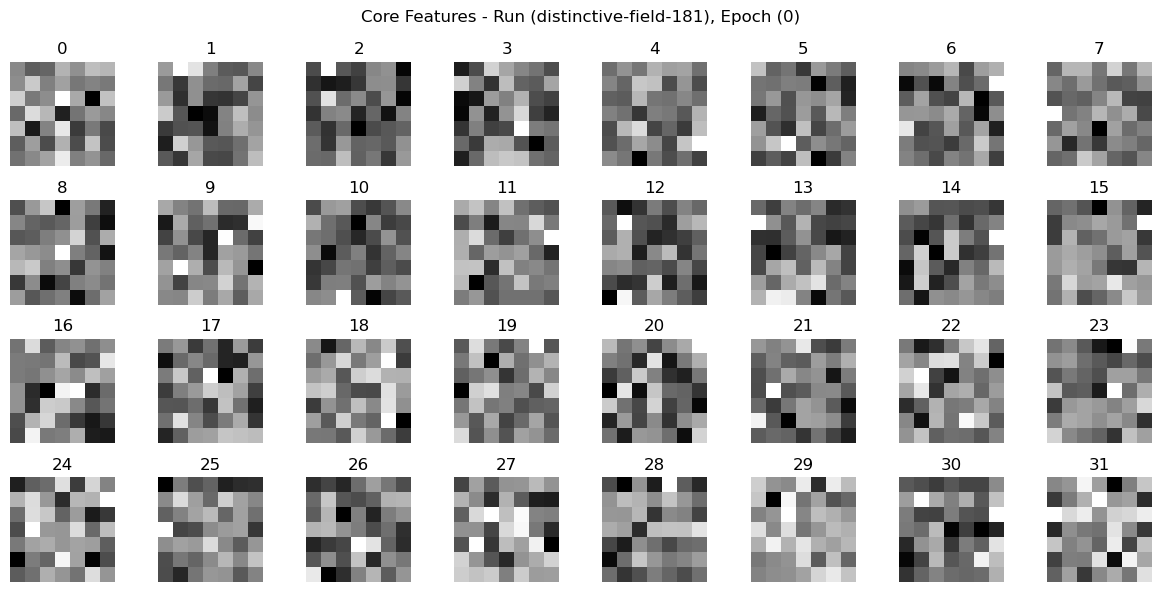

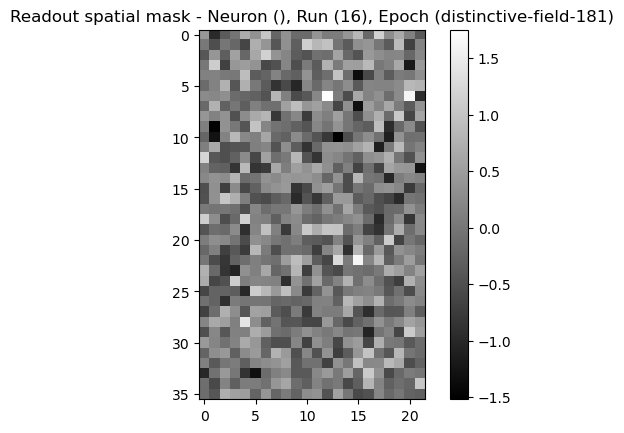

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 0: loss=-3.16, pred_std_neuron=1.10, y_std=10.62, validation_correlation=0.42, validation_loss=-5.33, 


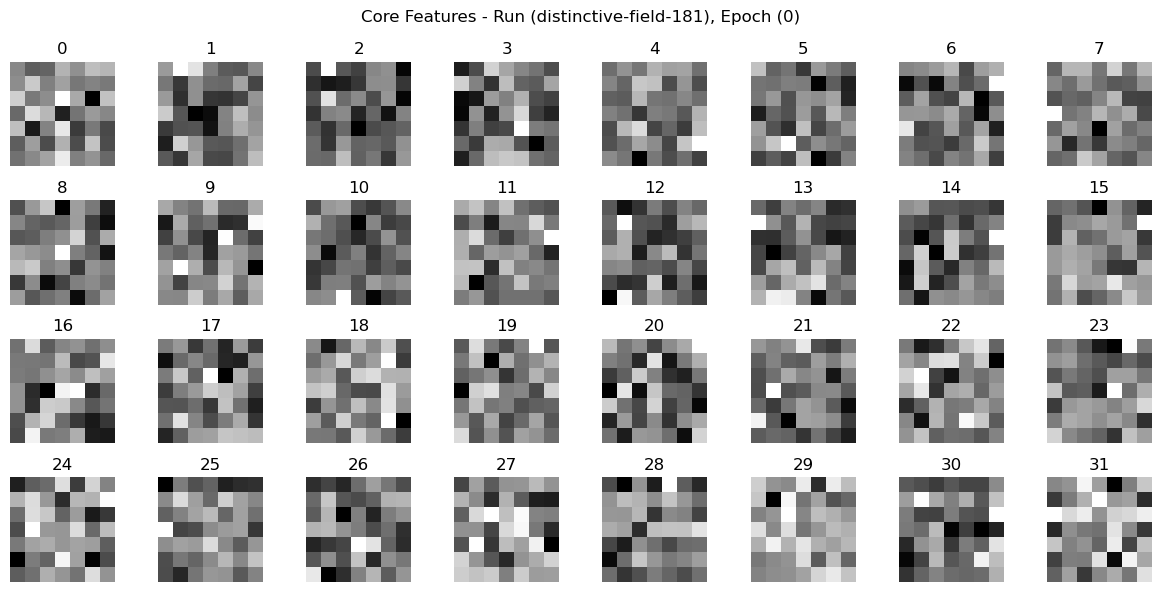

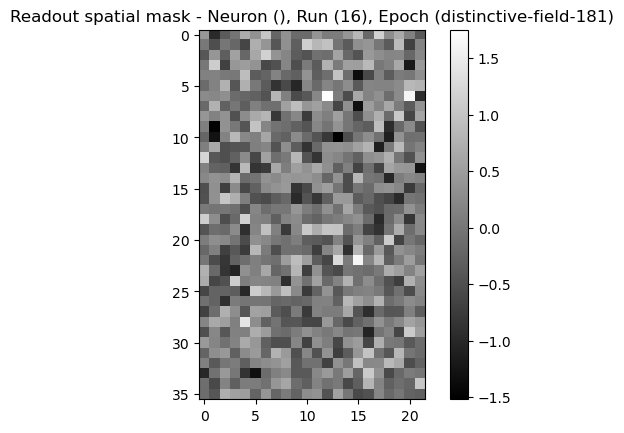

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 0: loss=0.50, pred_std_neuron=1.31, y_std=7.36, validation_correlation=0.36, validation_loss=-2.44, 


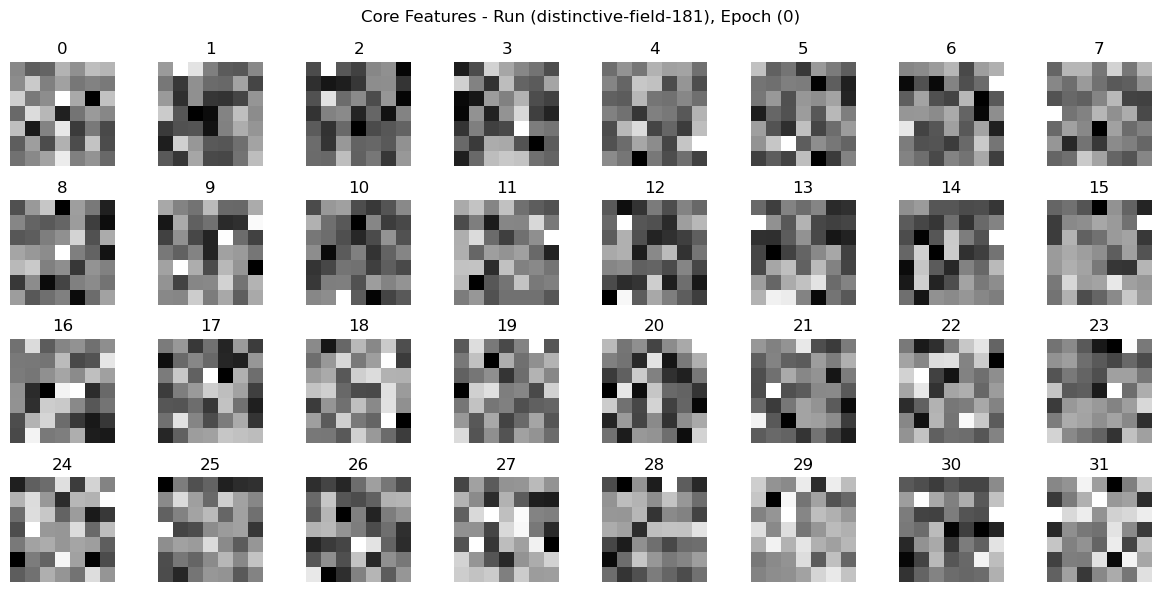

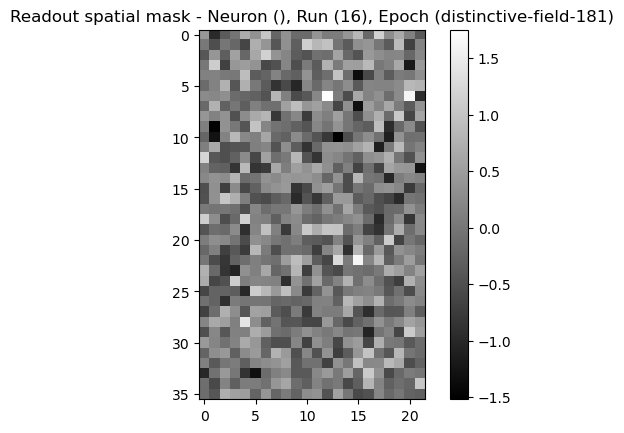

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 5: loss=-0.85, pred_std_neuron=1.10, y_std=6.51, validation_correlation=0.34, validation_loss=-1.70, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 5: loss=-4.92, pred_std_neuron=1.10, y_std=12.36, validation_correlation=0.43, validation_loss=-5.52, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 5: loss=-1.45, pred_std_neuron=1.40, y_std=6.87, validation_correlation=0.37, validation_loss=-2.56, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023

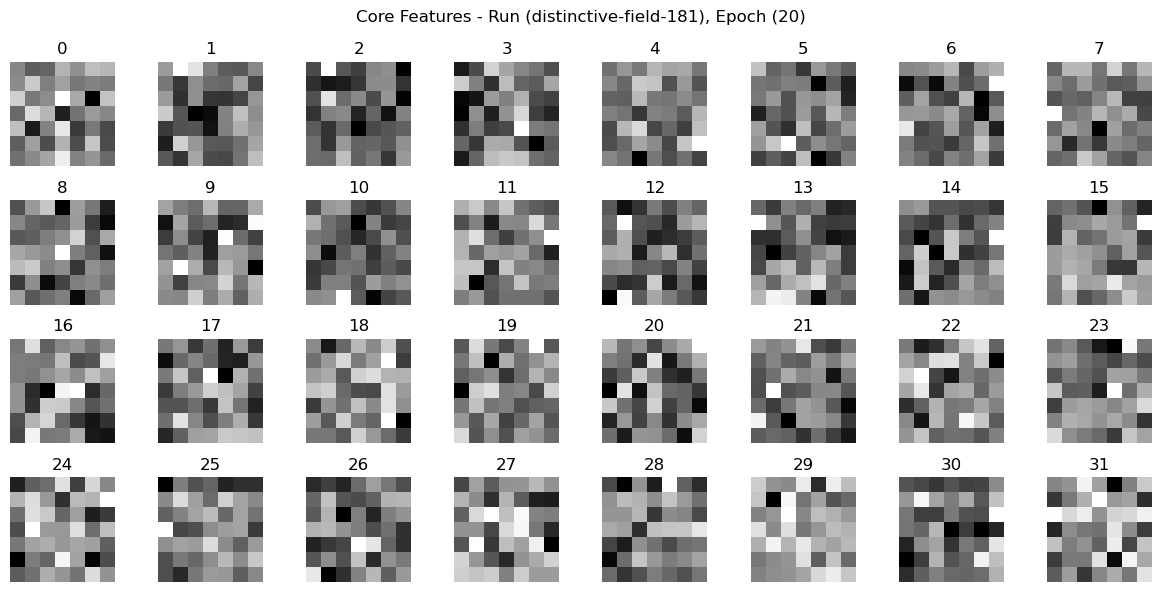

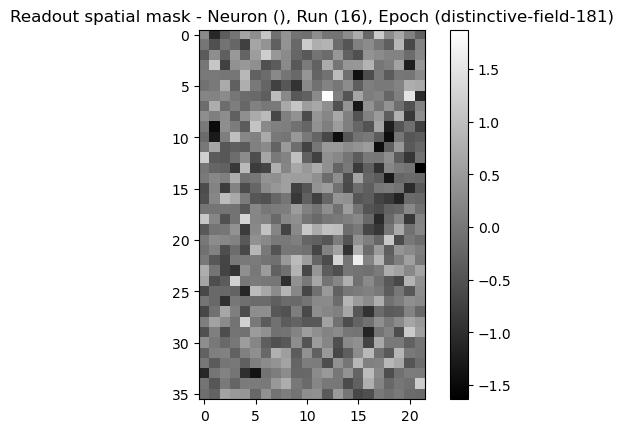

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 20: loss=-5.88, pred_std_neuron=1.19, y_std=13.01, validation_correlation=0.44, validation_loss=-5.73, 


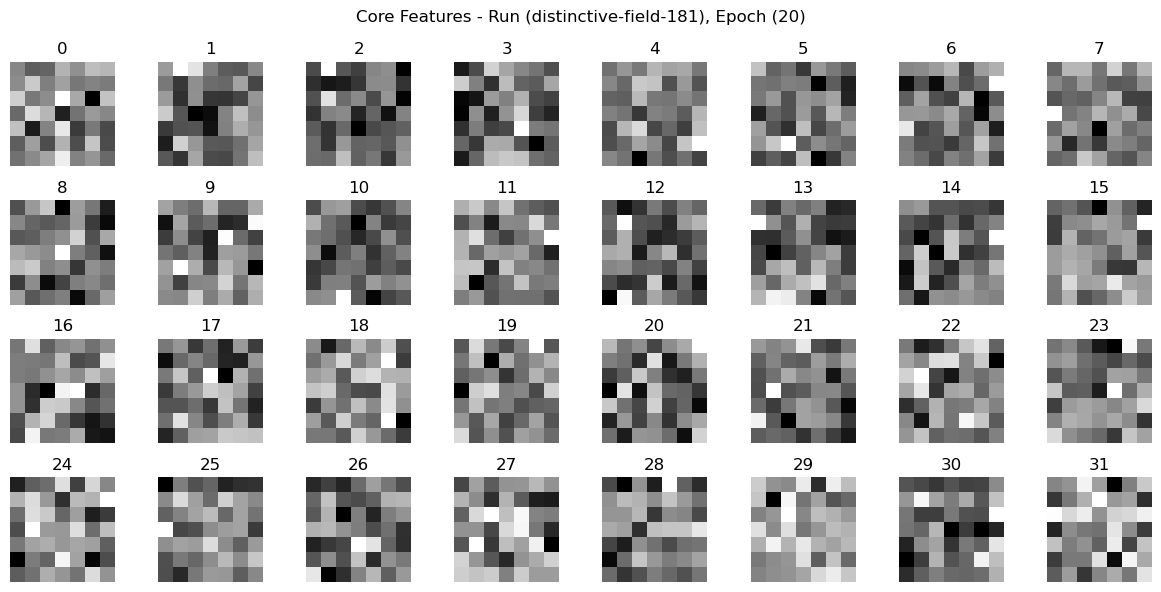

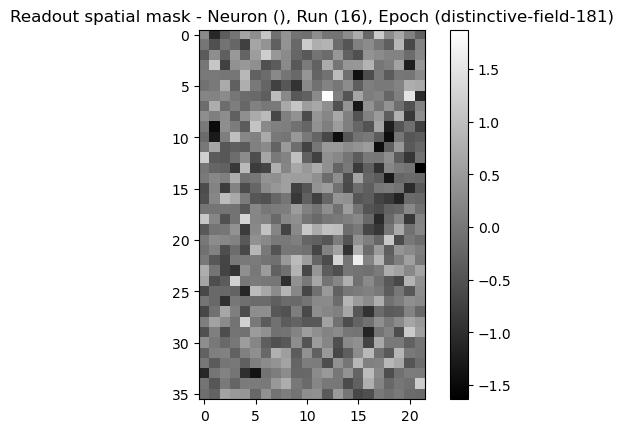

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 20: loss=-2.37, pred_std_neuron=1.48, y_std=6.52, validation_correlation=0.38, validation_loss=-2.74, 


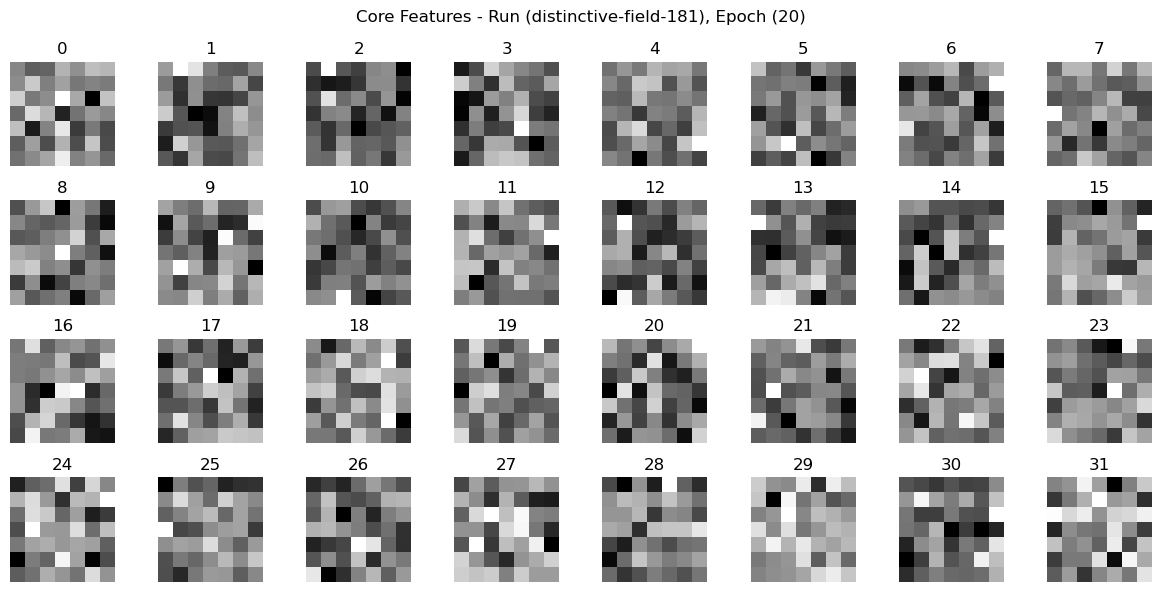

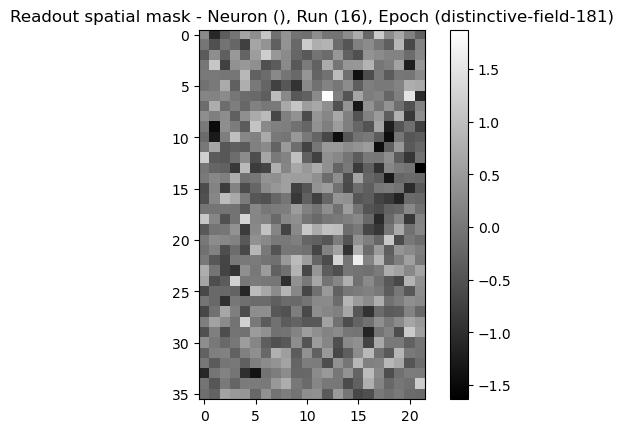

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 25: loss=-1.79, pred_std_neuron=1.22, y_std=8.12, validation_correlation=0.38, validation_loss=-1.99, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 25: loss=-5.96, pred_std_neuron=1.16, y_std=12.75, validation_correlation=0.44, validation_loss=-5.74, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 25: loss=-2.43, pred_std_neuron=1.43, y_std=9.32, validation_correlation=0.39, validation_loss=-2.76, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2

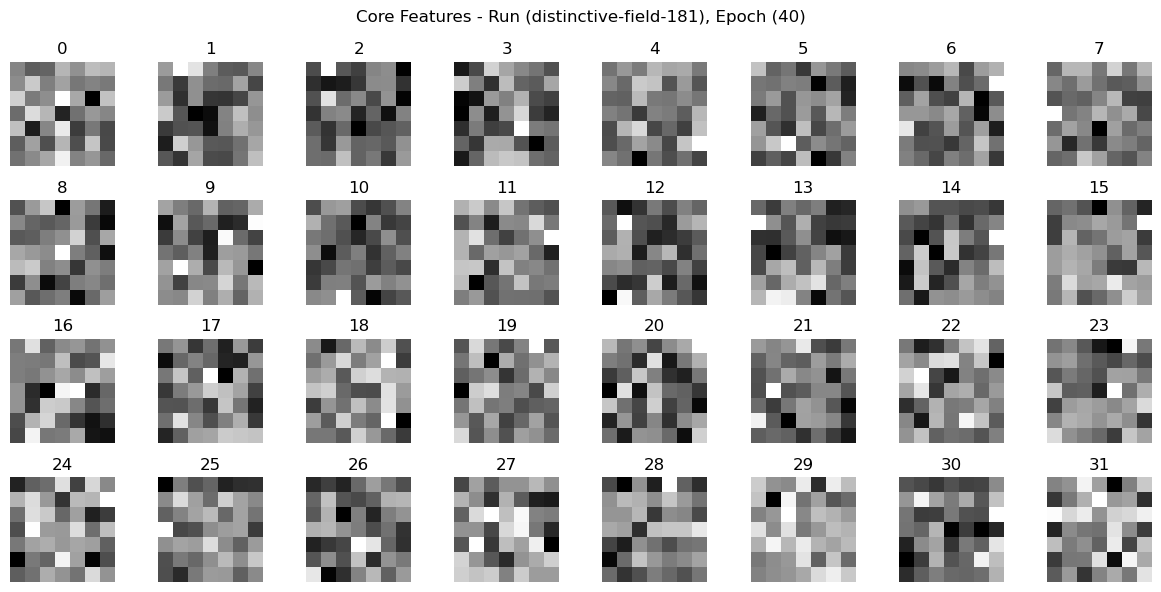

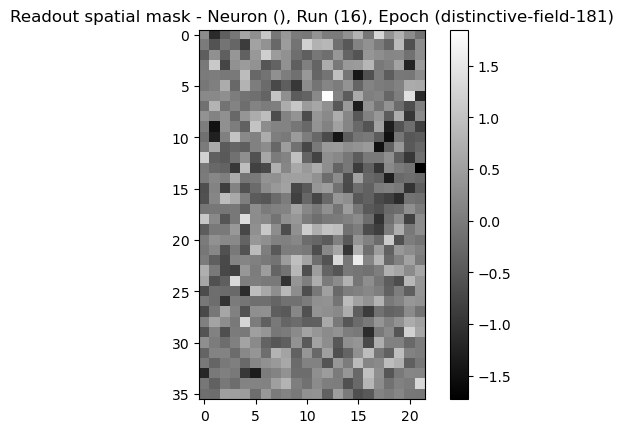

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 40: loss=-6.08, pred_std_neuron=1.18, y_std=11.70, validation_correlation=0.45, validation_loss=-5.74, 


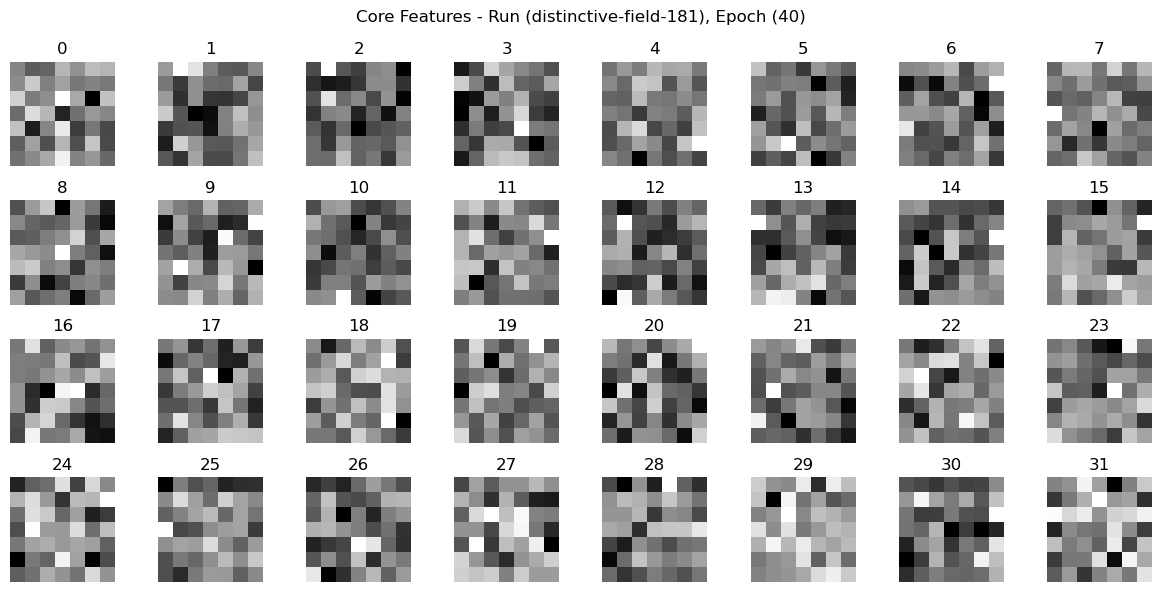

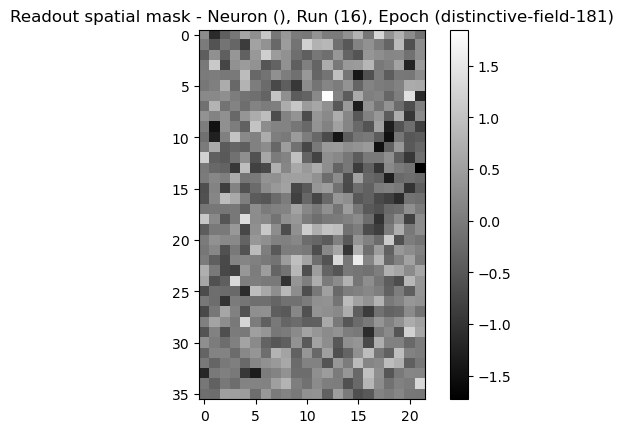

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 40: loss=-2.53, pred_std_neuron=1.52, y_std=8.04, validation_correlation=0.38, validation_loss=-2.77, 


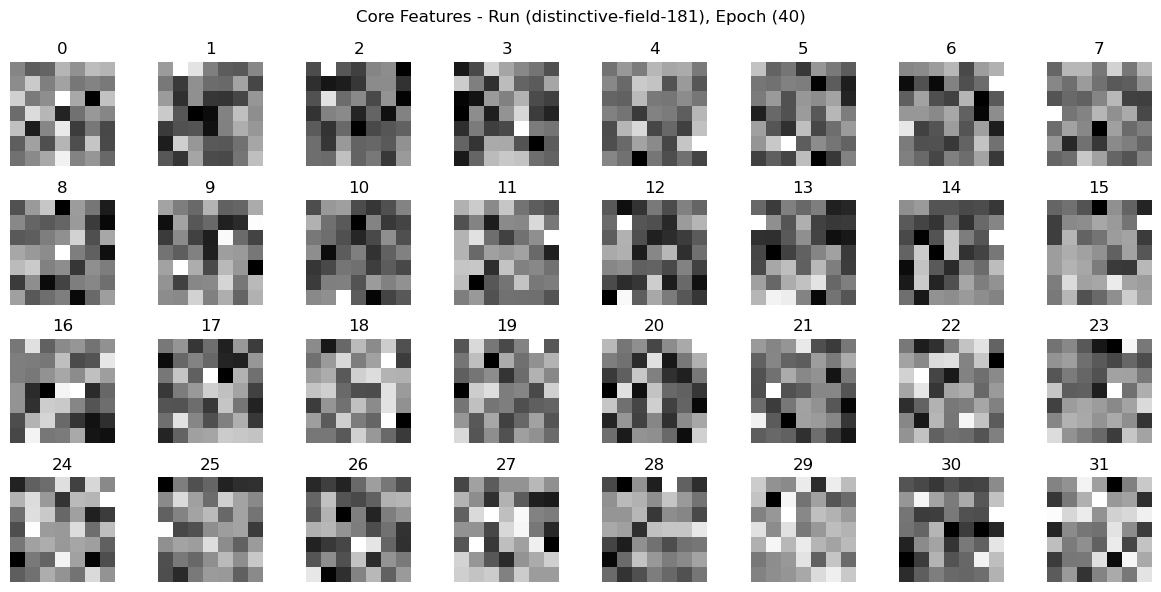

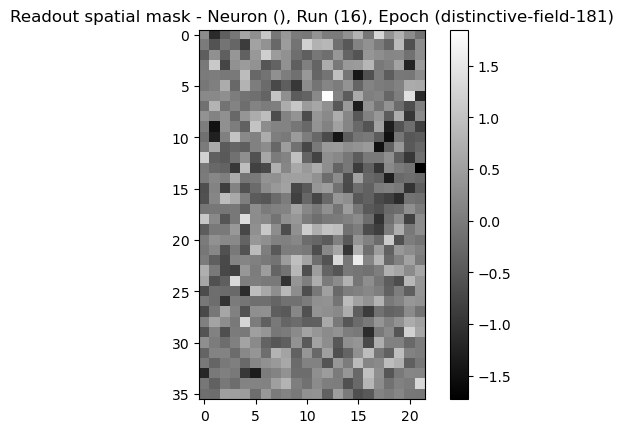

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 45: loss=-1.90, pred_std_neuron=1.29, y_std=8.84, validation_correlation=0.37, validation_loss=-2.01, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 45: loss=-6.10, pred_std_neuron=1.20, y_std=8.93, validation_correlation=0.44, validation_loss=-5.76, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 45: loss=-2.55, pred_std_neuron=1.54, y_std=7.50, validation_correlation=0.38, validation_loss=-2.77, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  20

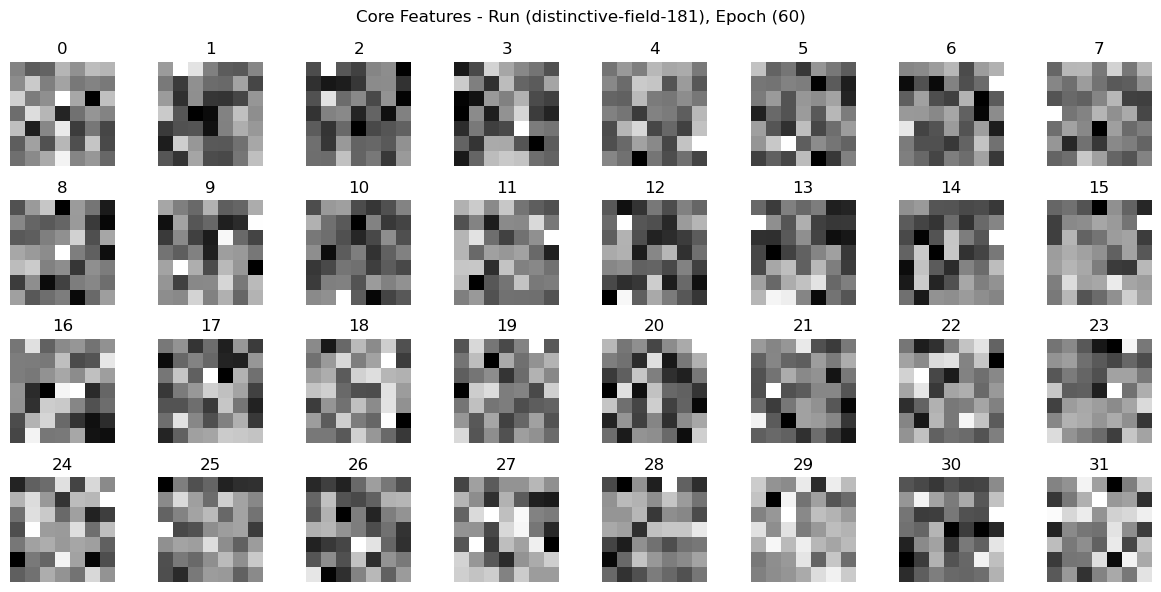

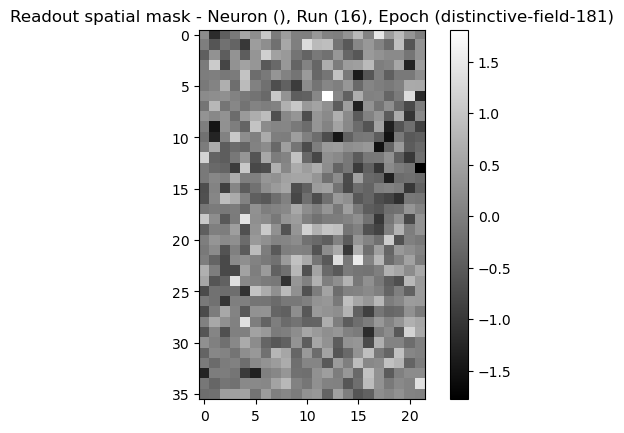

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 60: loss=-6.16, pred_std_neuron=1.19, y_std=11.02, validation_correlation=0.44, validation_loss=-5.75, 


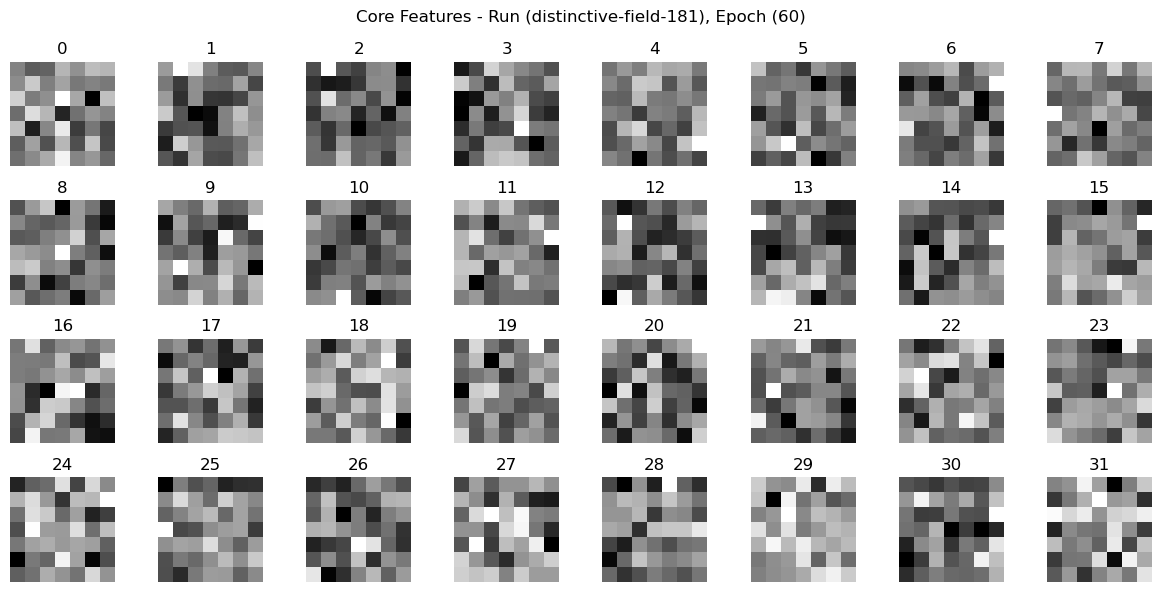

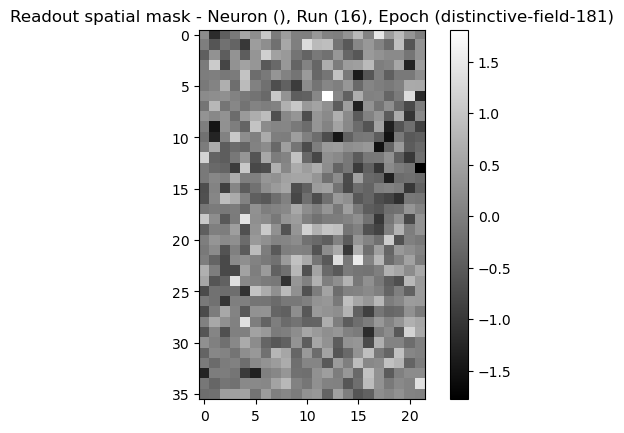

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 60: loss=-2.59, pred_std_neuron=1.53, y_std=8.16, validation_correlation=0.38, validation_loss=-2.77, 


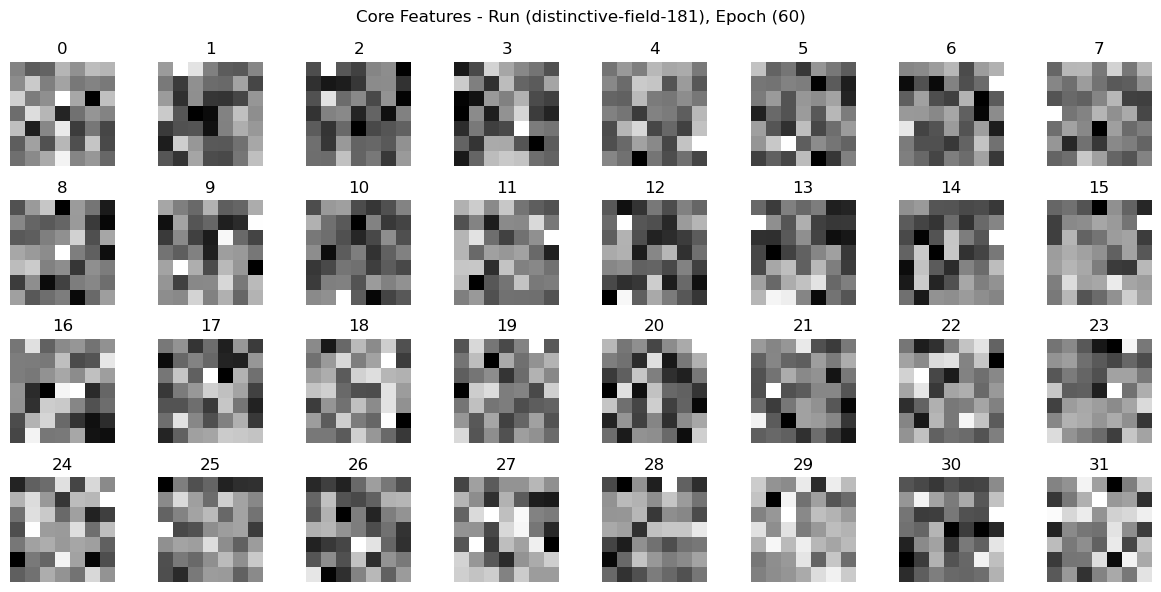

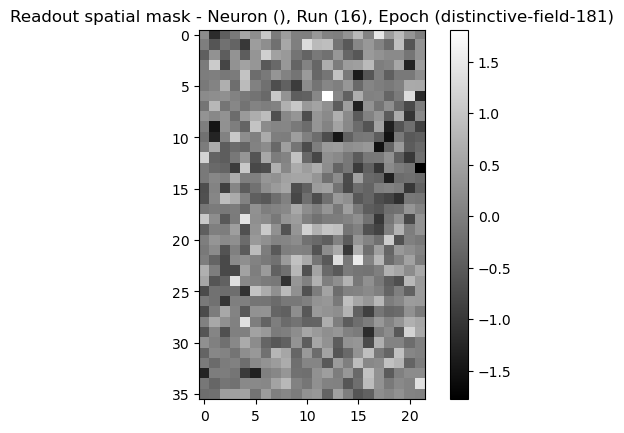

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 65: loss=-1.96, pred_std_neuron=1.31, y_std=7.68, validation_correlation=0.37, validation_loss=-2.00, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 65: loss=-6.17, pred_std_neuron=1.20, y_std=11.80, validation_correlation=0.45, validation_loss=-5.74, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 65: loss=-2.61, pred_std_neuron=1.51, y_std=8.27, validation_correlation=0.38, validation_loss=-2.76, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2

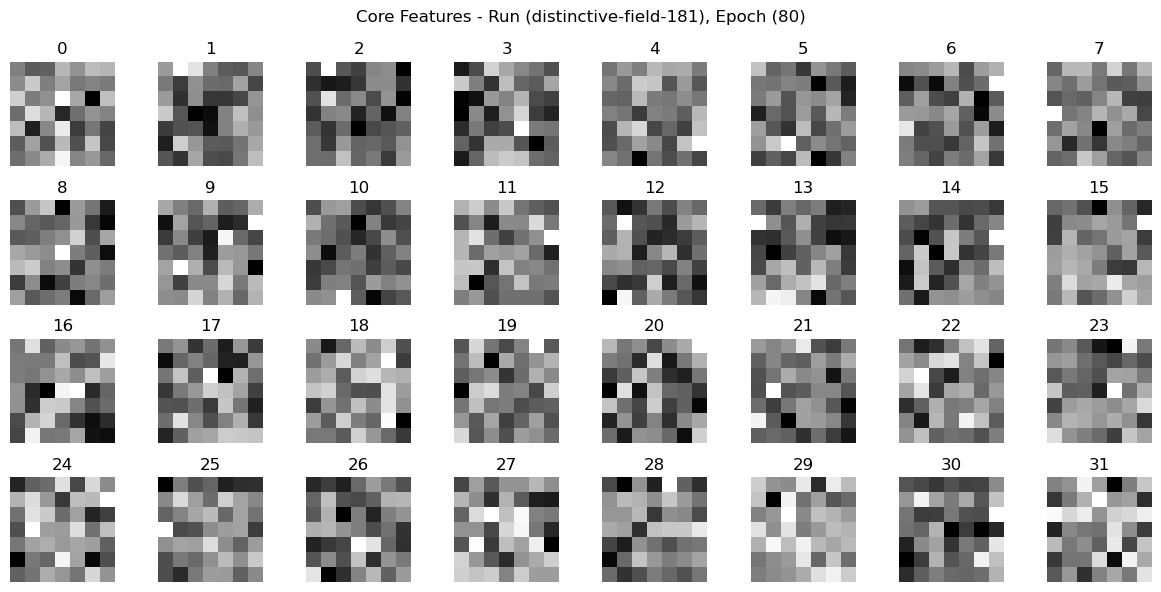

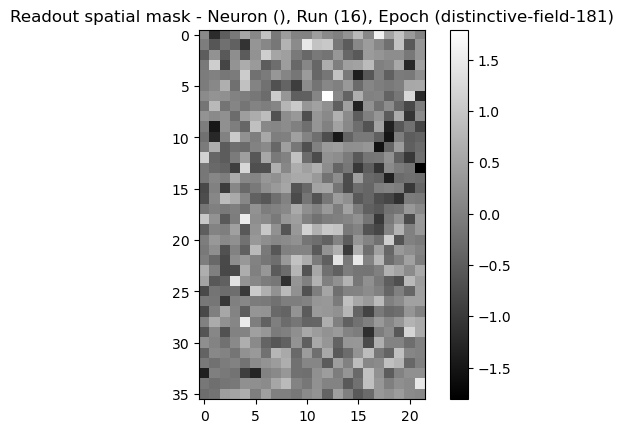

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 80: loss=-6.21, pred_std_neuron=1.23, y_std=11.92, validation_correlation=0.44, validation_loss=-5.73, 


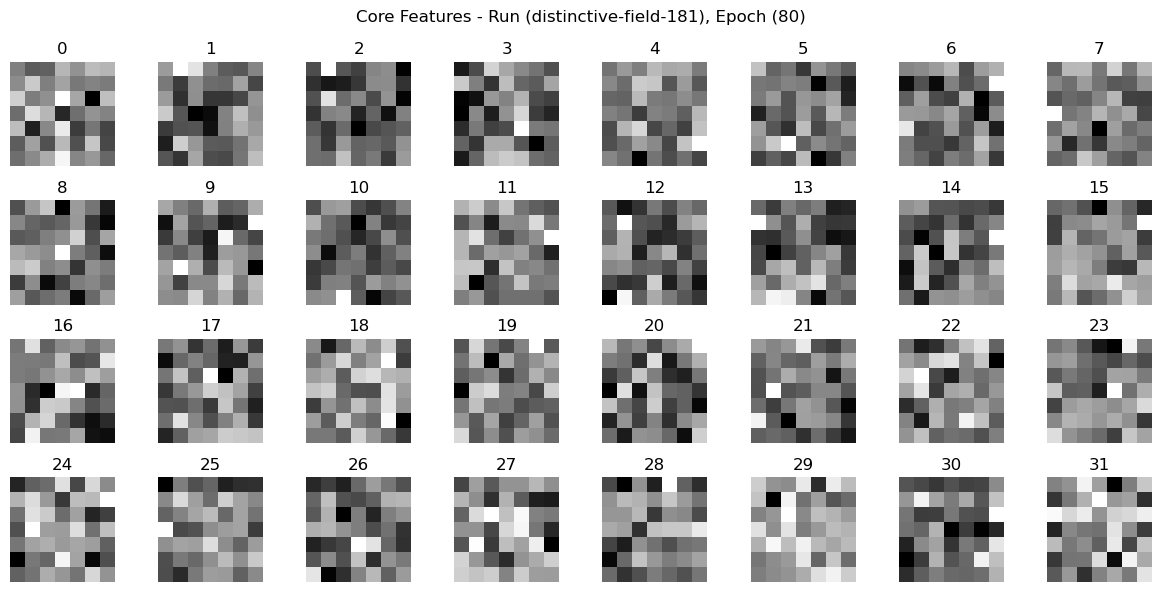

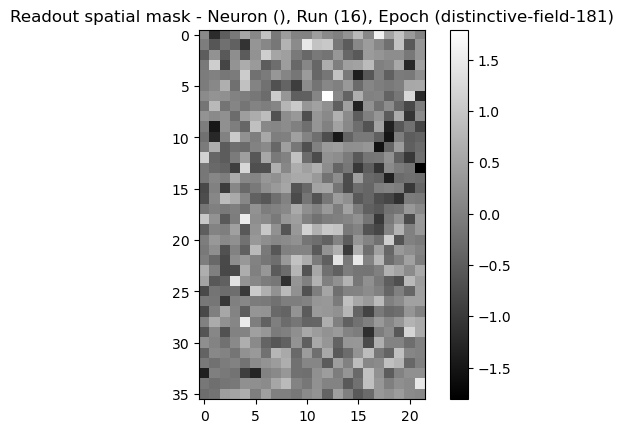

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 80: loss=-2.64, pred_std_neuron=1.58, y_std=8.69, validation_correlation=0.38, validation_loss=-2.75, 


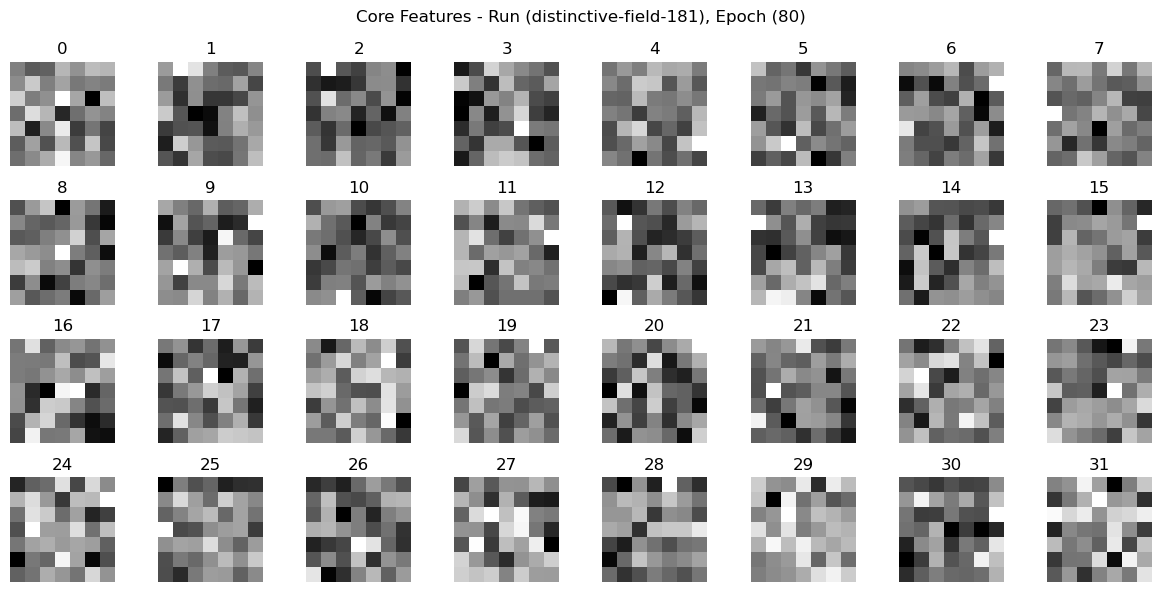

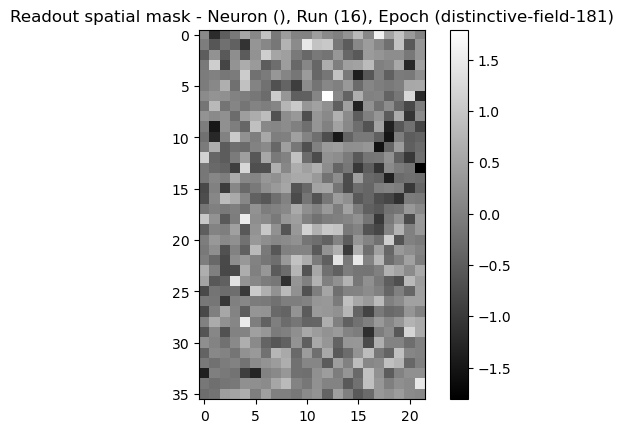

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 85: loss=-2.00, pred_std_neuron=1.32, y_std=7.35, validation_correlation=0.37, validation_loss=-1.98, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 85: loss=-6.22, pred_std_neuron=1.26, y_std=13.69, validation_correlation=0.44, validation_loss=-5.73, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 85: loss=-2.64, pred_std_neuron=1.62, y_std=7.19, validation_correlation=0.37, validation_loss=-2.75, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2

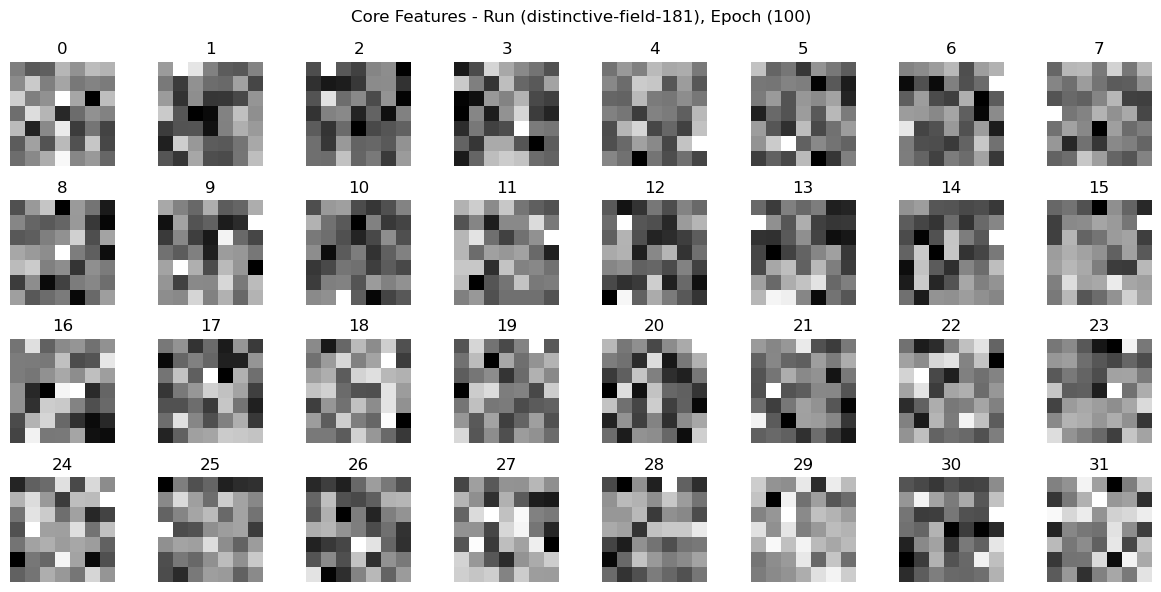

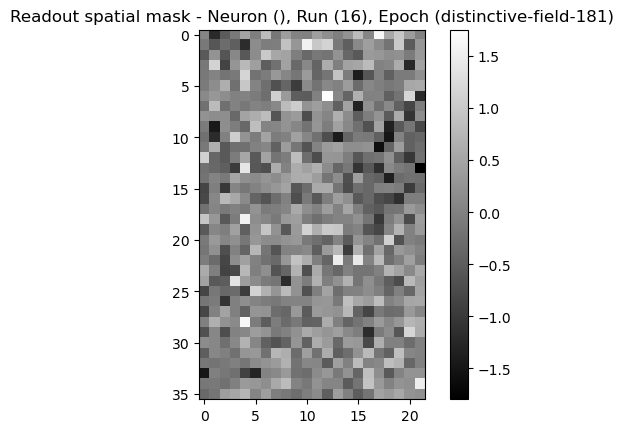

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 100: loss=-6.25, pred_std_neuron=1.25, y_std=10.24, validation_correlation=0.43, validation_loss=-5.71, 


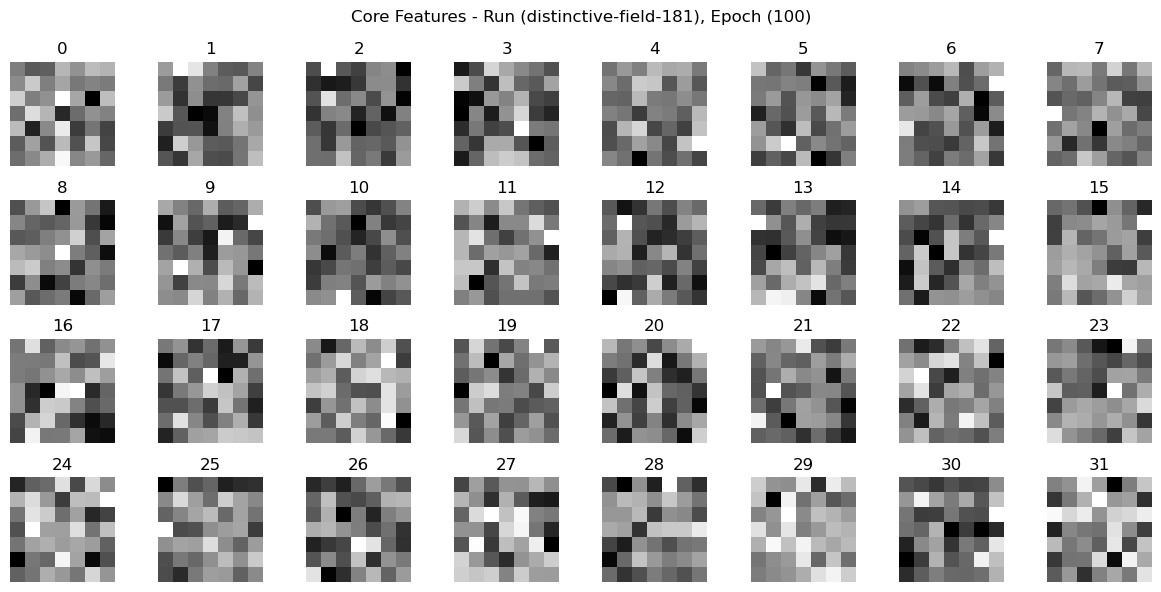

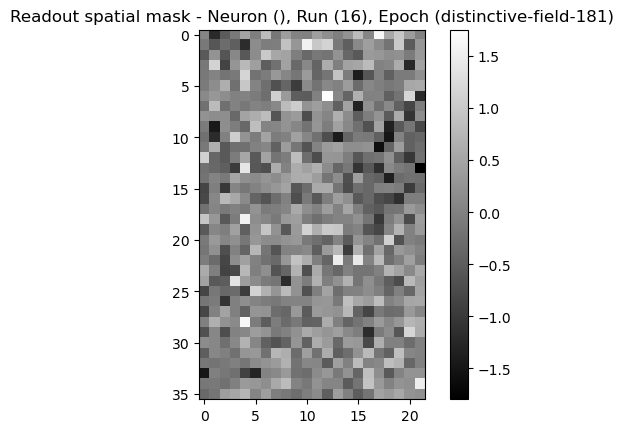

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 100: loss=-2.67, pred_std_neuron=1.63, y_std=7.87, validation_correlation=0.37, validation_loss=-2.73, 


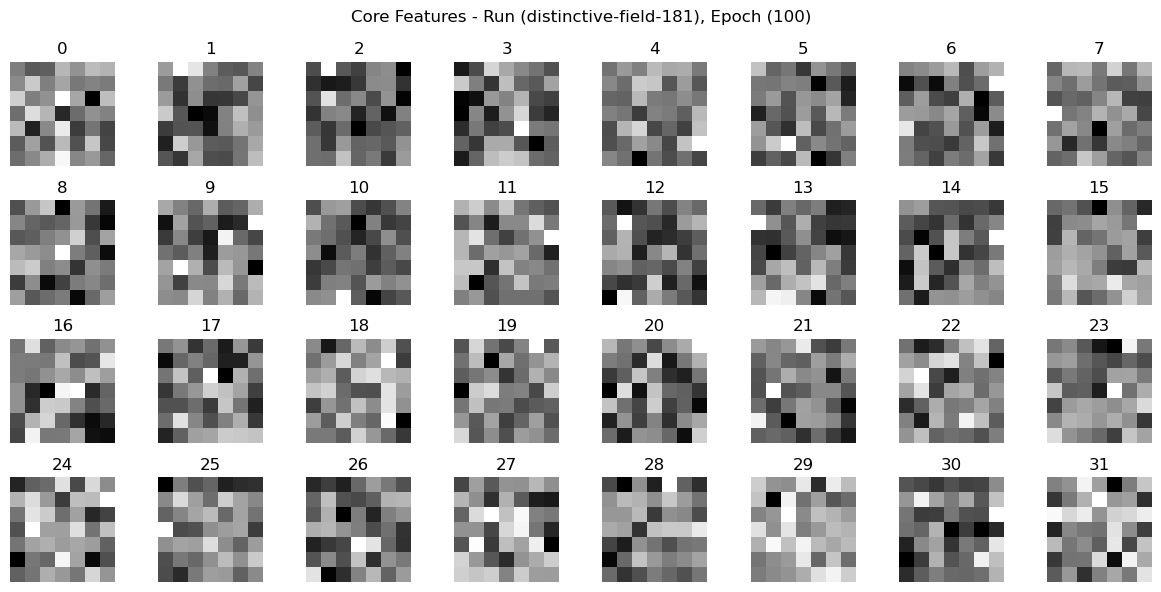

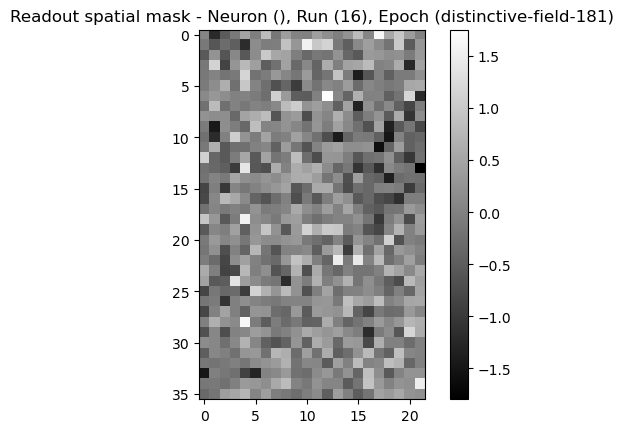

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 105: loss=-2.04, pred_std_neuron=1.35, y_std=8.60, validation_correlation=0.36, validation_loss=-1.96, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 105: loss=-6.26, pred_std_neuron=1.26, y_std=11.22, validation_correlation=0.43, validation_loss=-5.71, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 105: loss=-2.68, pred_std_neuron=1.59, y_std=7.55, validation_correlation=0.37, validation_loss=-2.72, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:

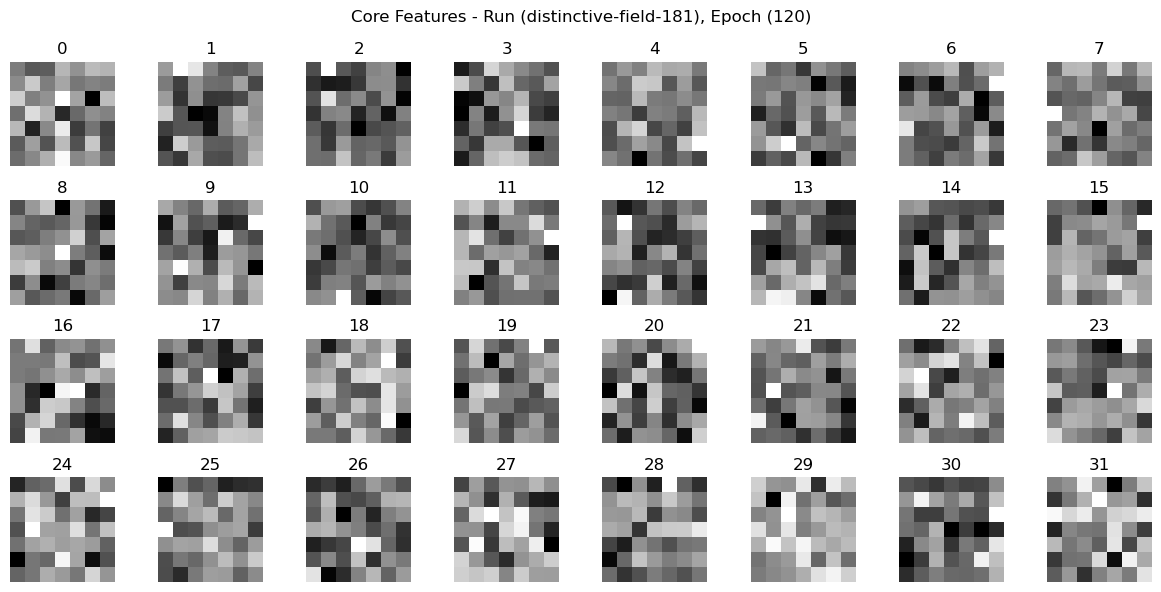

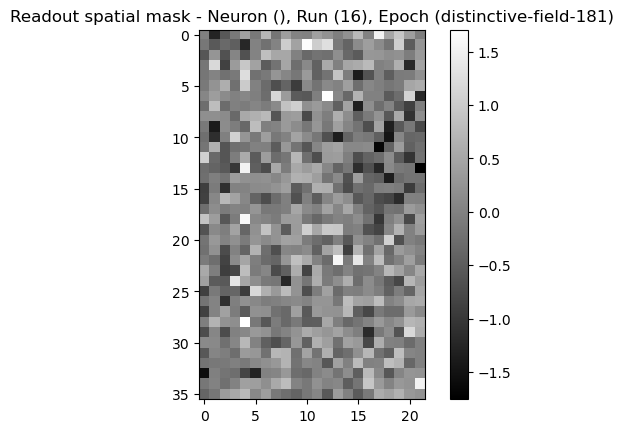

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 120: loss=-6.30, pred_std_neuron=1.30, y_std=8.38, validation_correlation=0.43, validation_loss=-5.67, 


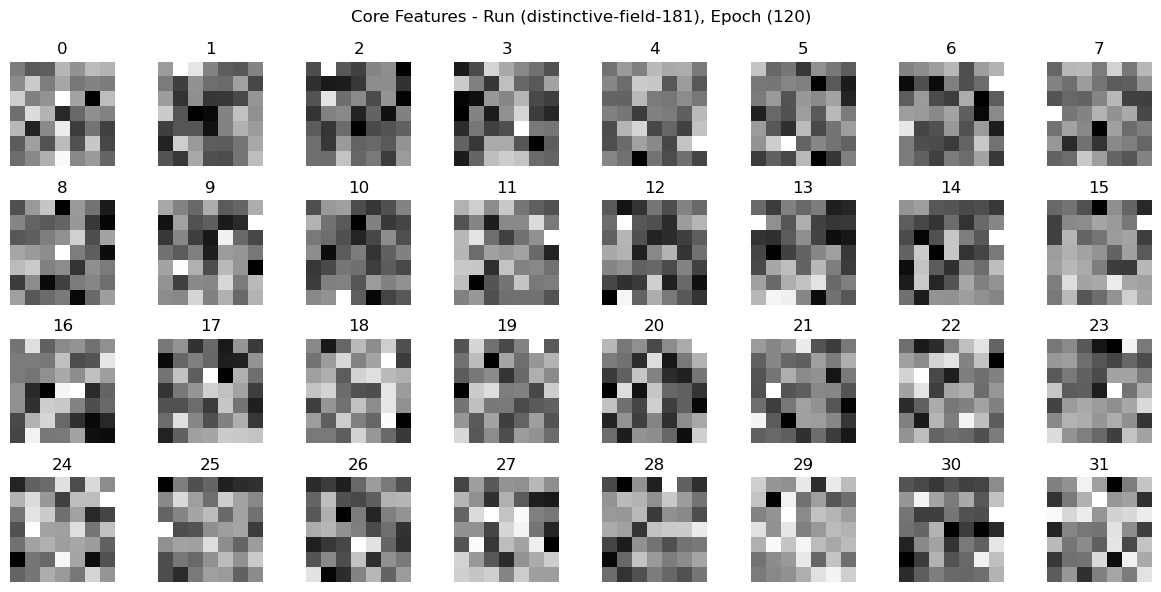

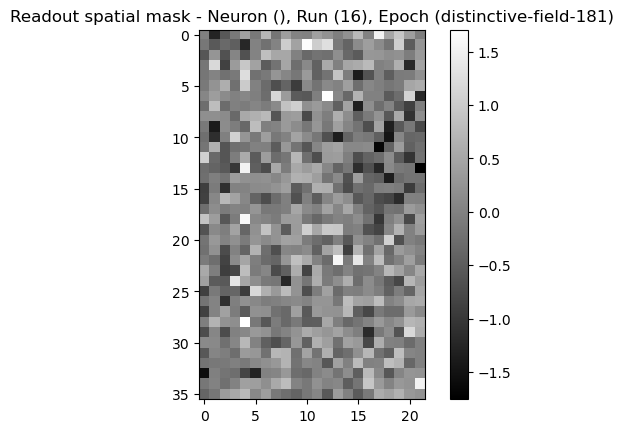

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 120: loss=-2.71, pred_std_neuron=1.69, y_std=9.97, validation_correlation=0.37, validation_loss=-2.70, 


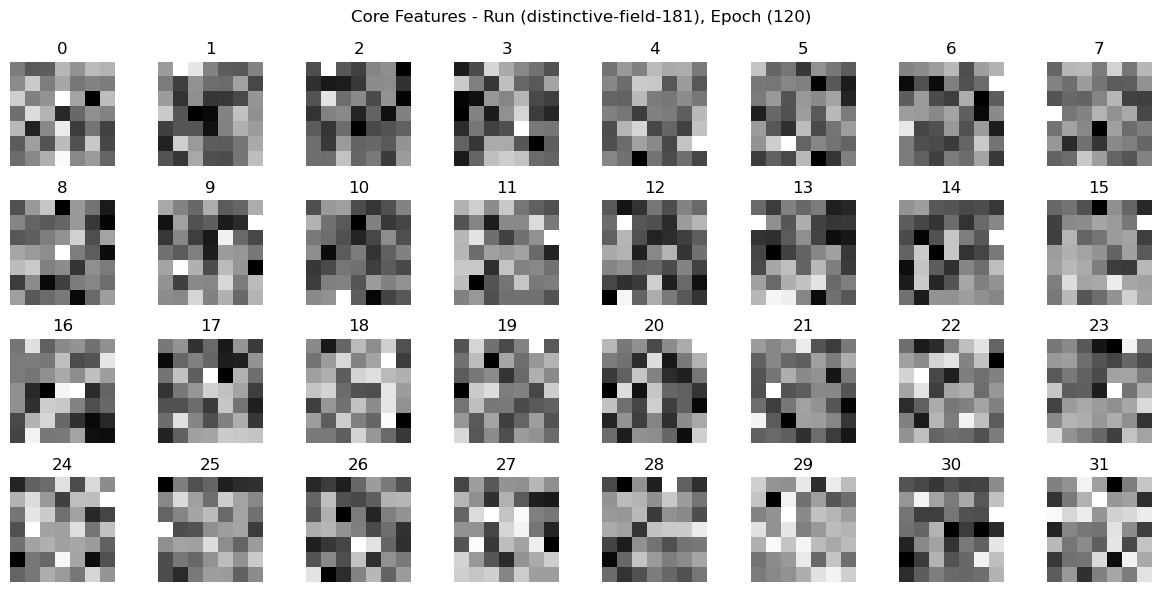

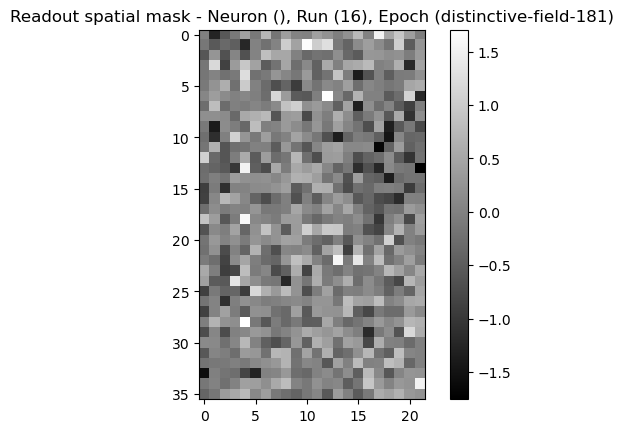

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 125: loss=-2.08, pred_std_neuron=1.39, y_std=9.55, validation_correlation=0.35, validation_loss=-1.93, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 125: loss=-6.31, pred_std_neuron=1.31, y_std=11.24, validation_correlation=0.43, validation_loss=-5.66, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 125: loss=-2.72, pred_std_neuron=1.66, y_std=8.58, validation_correlation=0.37, validation_loss=-2.70, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:

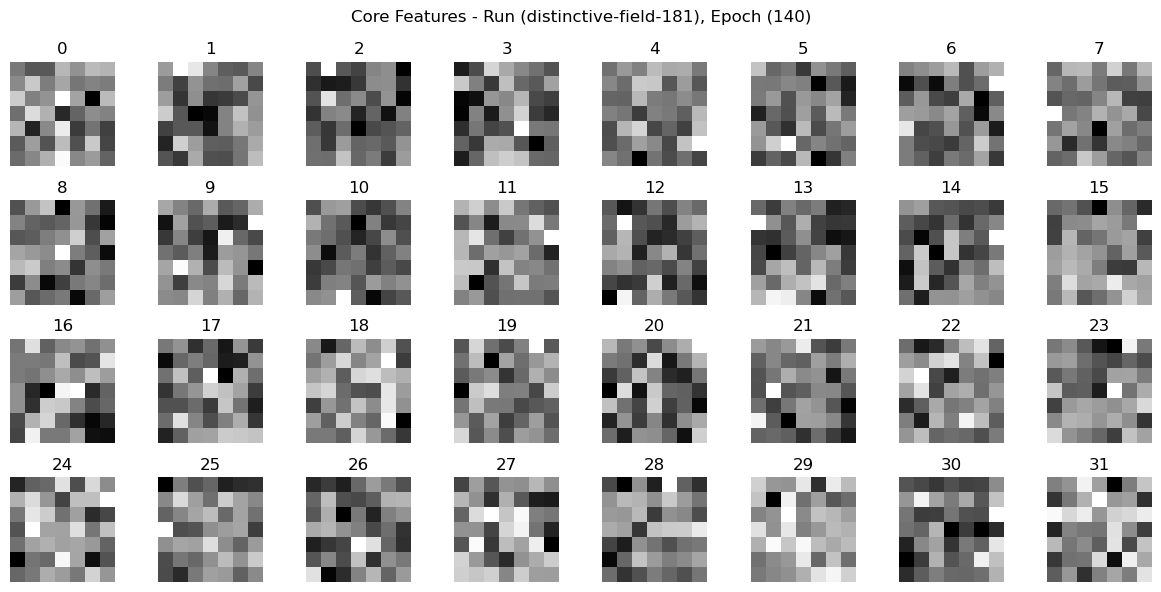

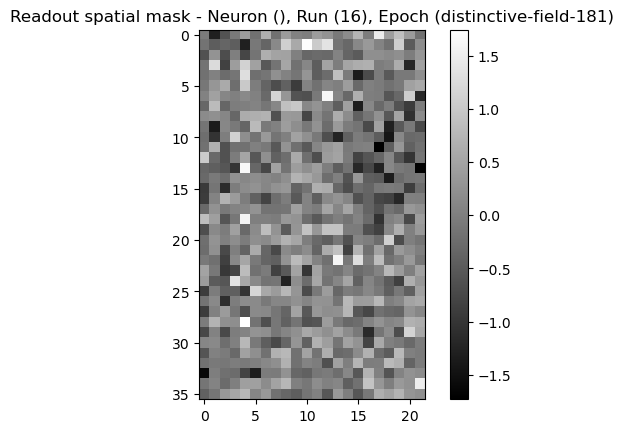

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 140: loss=-6.35, pred_std_neuron=1.36, y_std=11.12, validation_correlation=0.42, validation_loss=-5.63, 


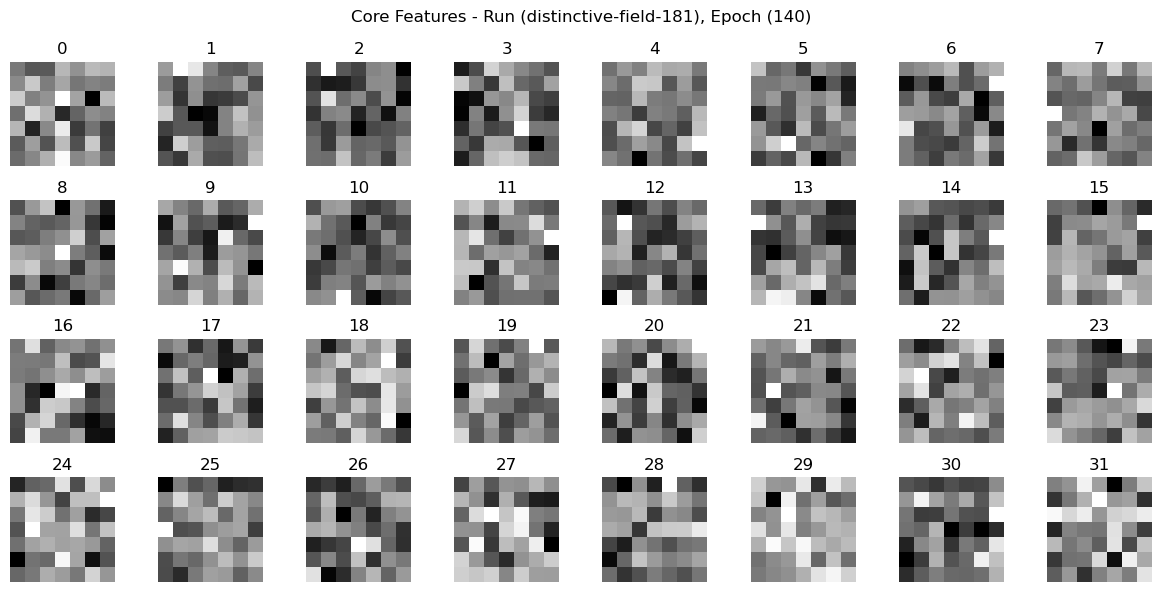

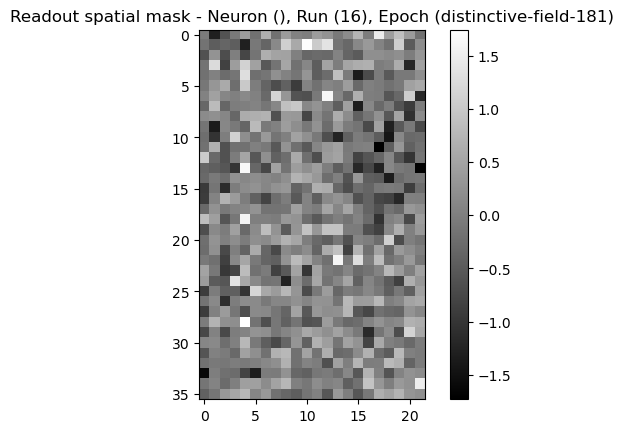

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 140: loss=-2.76, pred_std_neuron=1.70, y_std=7.90, validation_correlation=0.37, validation_loss=-2.67, 


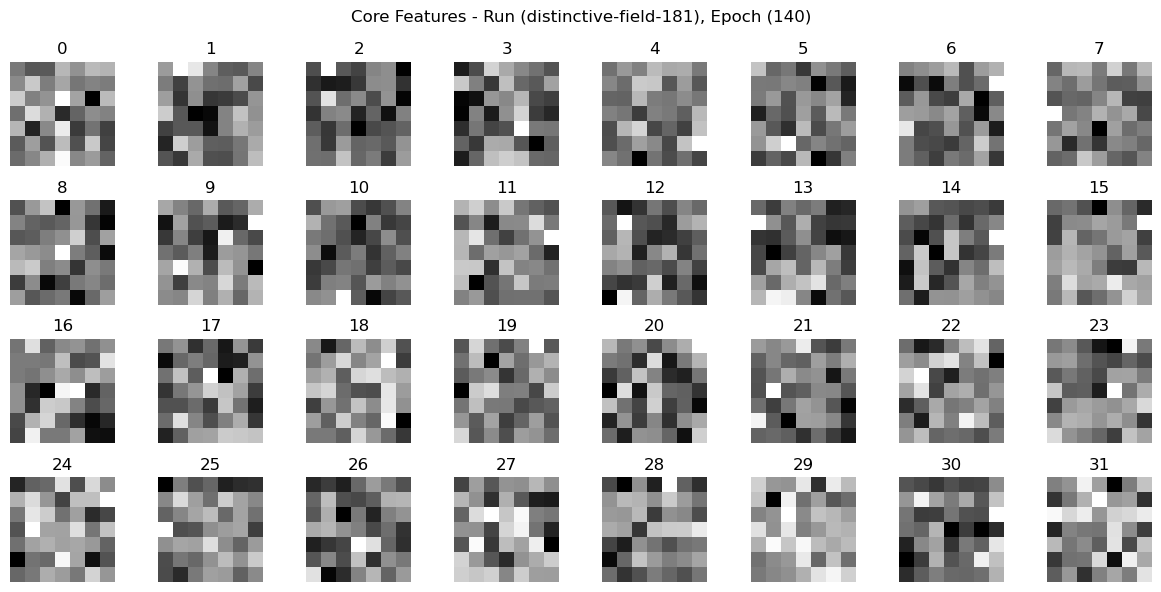

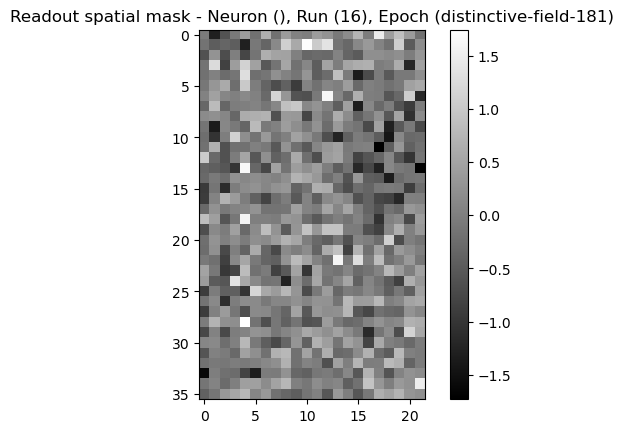

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 145: loss=-2.13, pred_std_neuron=1.42, y_std=7.80, validation_correlation=0.35, validation_loss=-1.89, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 145: loss=-6.36, pred_std_neuron=1.27, y_std=11.33, validation_correlation=0.43, validation_loss=-5.60, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 145: loss=-2.77, pred_std_neuron=1.73, y_std=7.74, validation_correlation=0.37, validation_loss=-2.65, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:

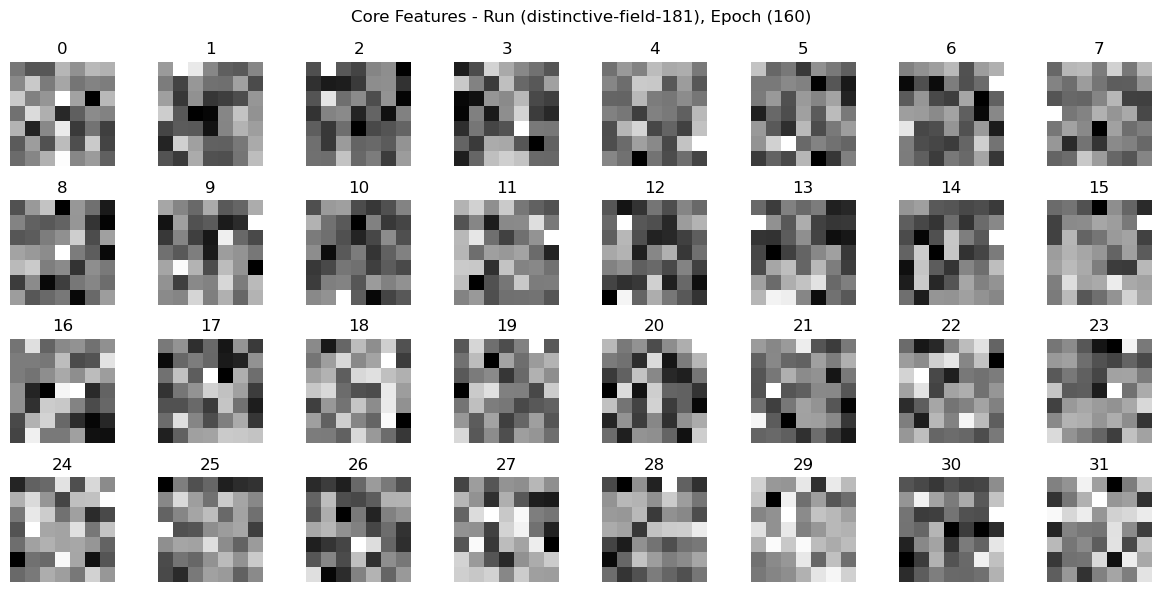

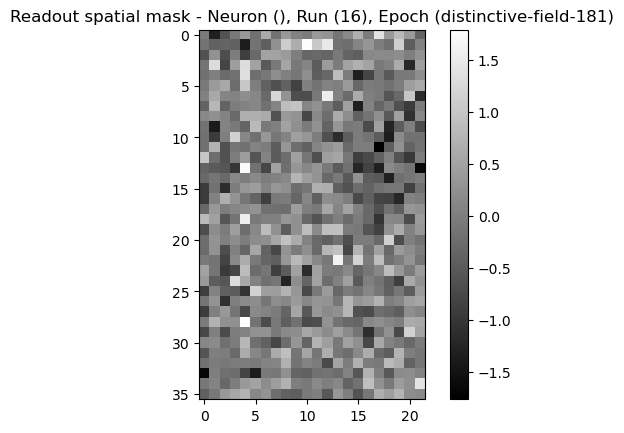

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 160: loss=-6.41, pred_std_neuron=1.34, y_std=11.38, validation_correlation=0.42, validation_loss=-5.57, 


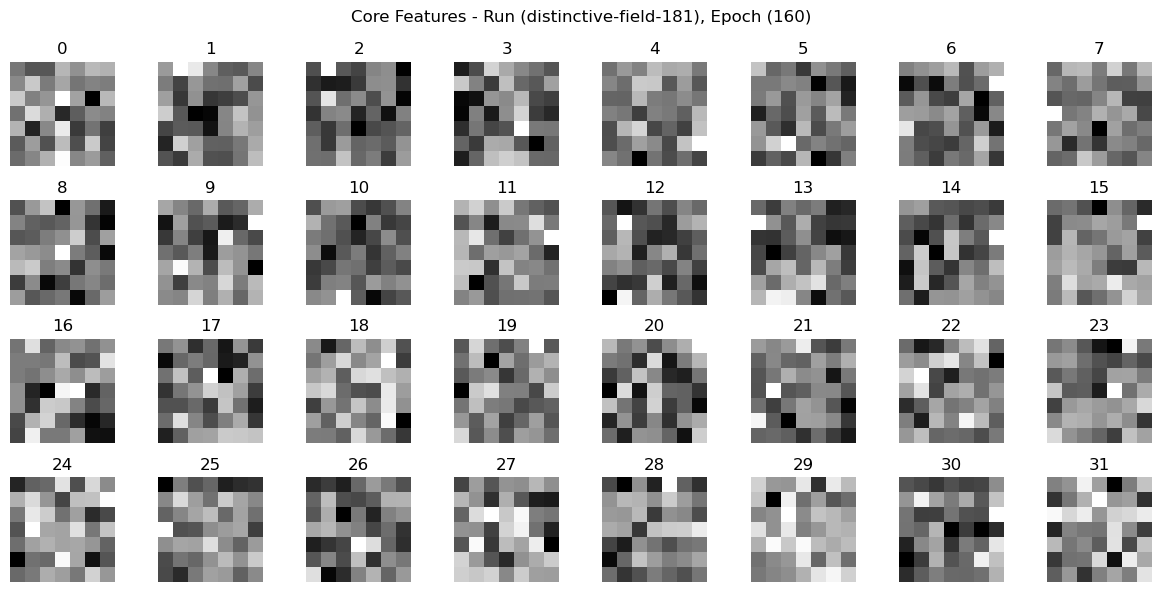

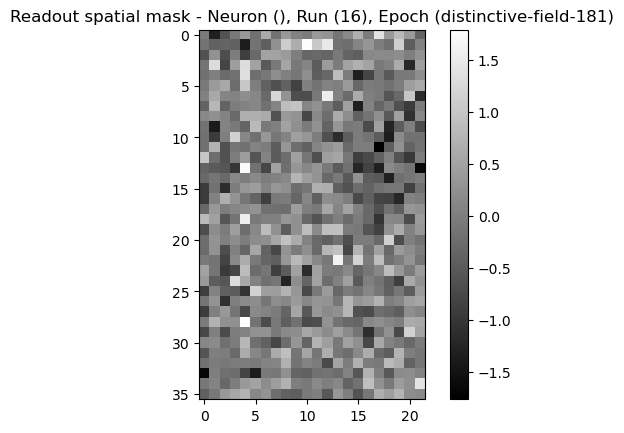

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 160: loss=-2.81, pred_std_neuron=1.81, y_std=6.23, validation_correlation=0.36, validation_loss=-2.61, 


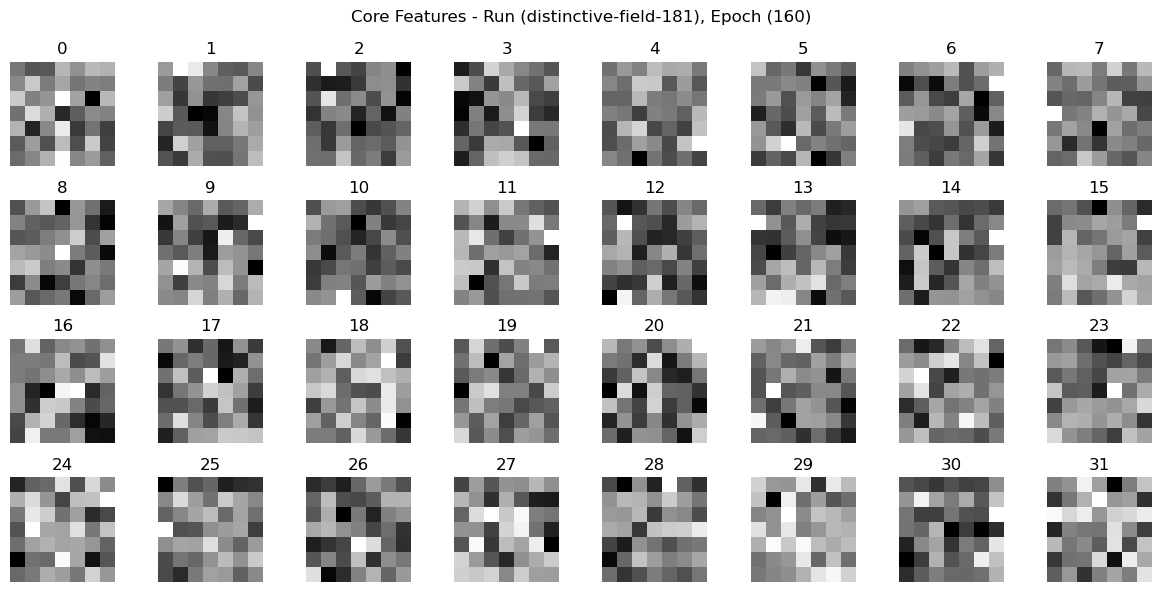

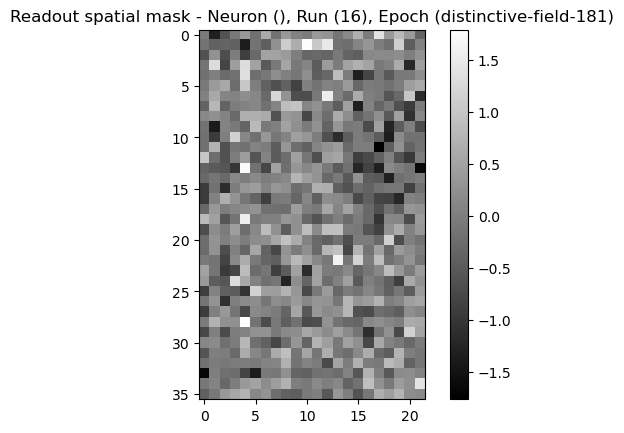

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 165: loss=-2.18, pred_std_neuron=1.51, y_std=8.06, validation_correlation=0.34, validation_loss=-1.83, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 165: loss=-6.43, pred_std_neuron=1.38, y_std=12.36, validation_correlation=0.41, validation_loss=-5.56, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 165: loss=-2.82, pred_std_neuron=1.76, y_std=8.34, validation_correlation=0.36, validation_loss=-2.60, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:

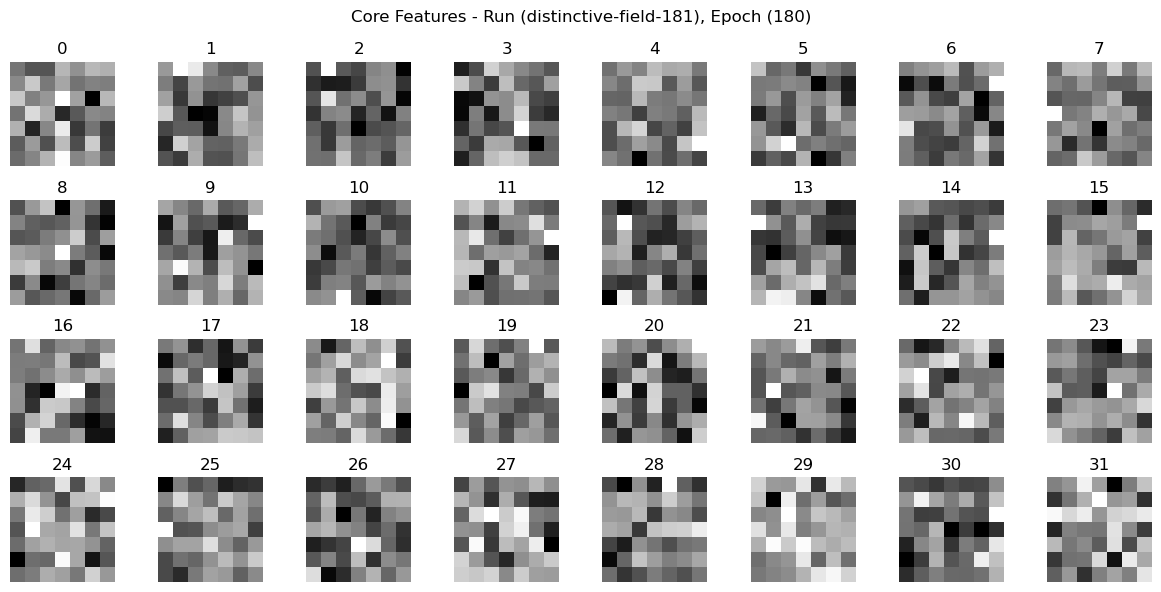

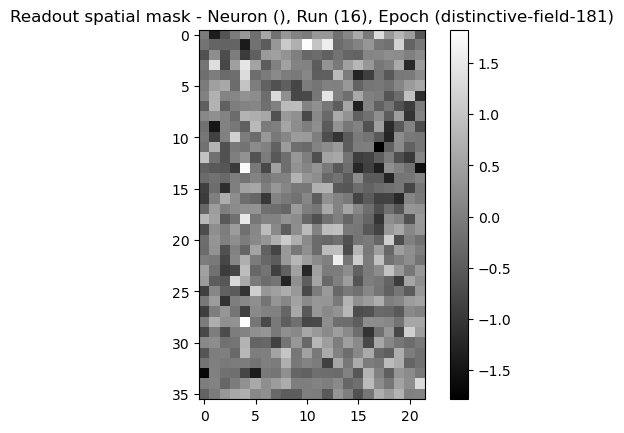

Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 180: loss=-6.48, pred_std_neuron=1.42, y_std=11.45, validation_correlation=0.41, validation_loss=-5.50, 


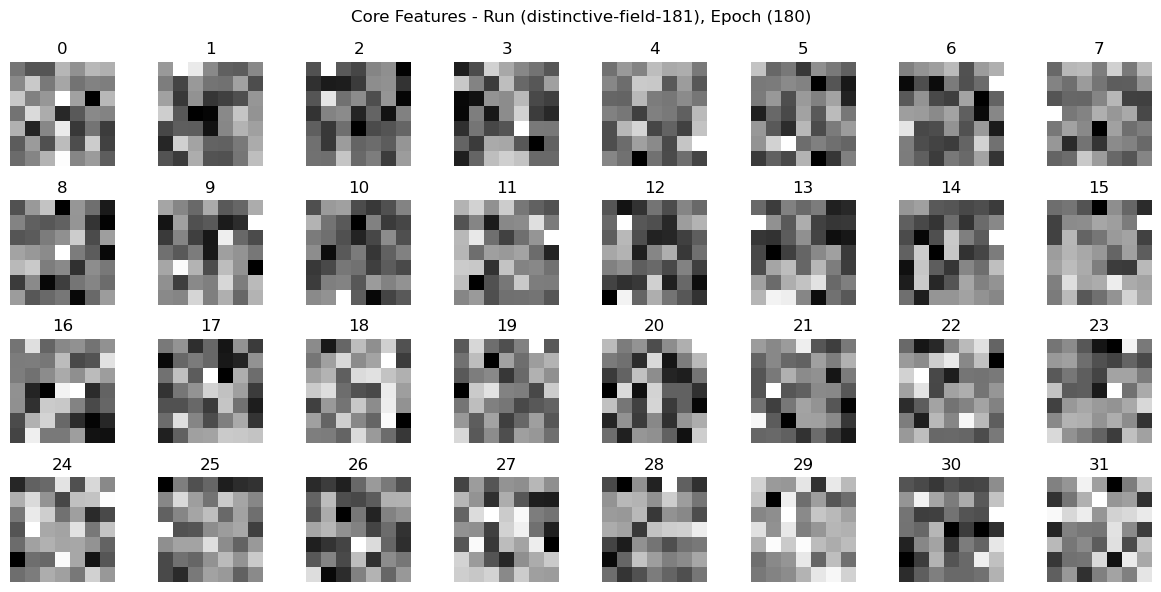

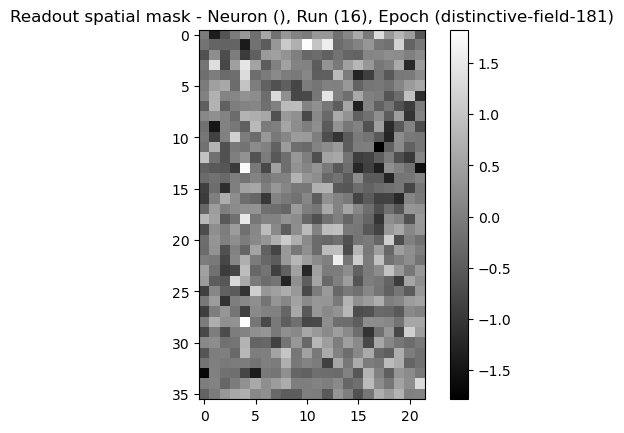

Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 180: loss=-2.87, pred_std_neuron=1.85, y_std=8.94, validation_correlation=0.35, validation_loss=-2.55, 


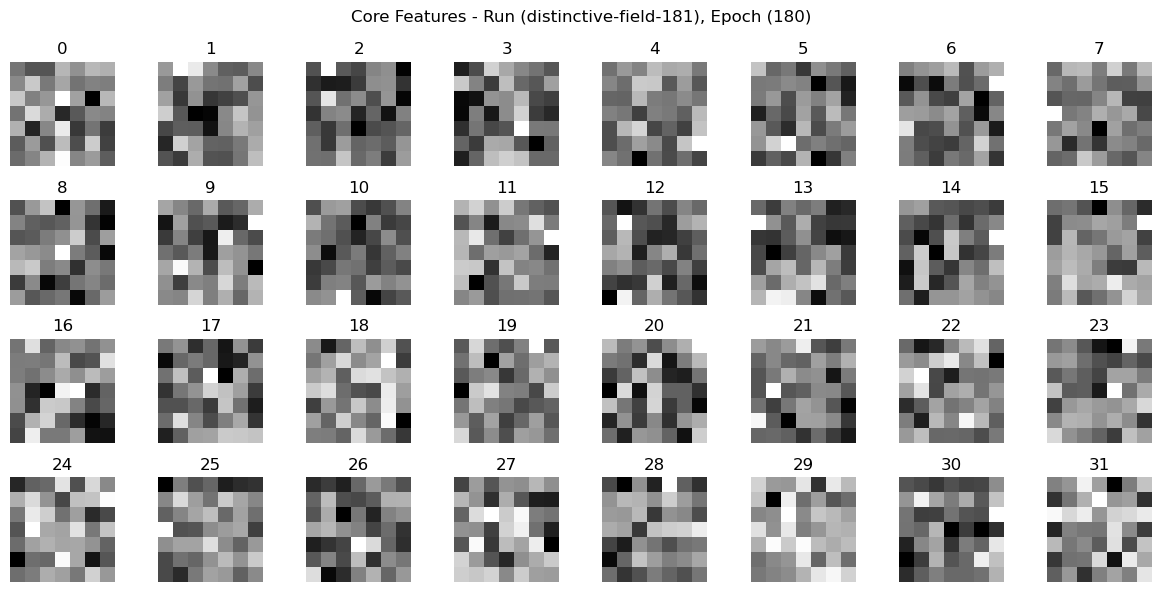

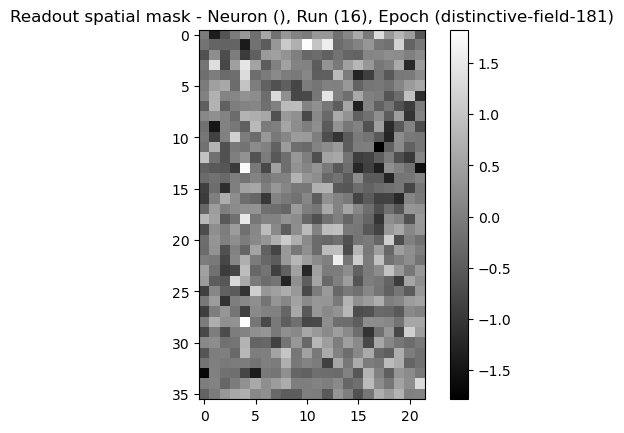

Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key:  2023-03-15_11-05

Currently learning for data_key:  2023-03-15_11-05
Epoch 185: loss=-2.25, pred_std_neuron=1.59, y_std=7.15, validation_correlation=0.33, validation_loss=-1.76, 
Data Key:  2023-03-15_15-23

Currently learning for data_key:  2023-03-15_15-23
Epoch 185: loss=-6.50, pred_std_neuron=1.36, y_std=9.73, validation_correlation=0.41, validation_loss=-5.47, 
Data Key:  2022-12-20_15-08

Currently learning for data_key:  2022-12-20_15-08
Epoch 185: loss=-2.88, pred_std_neuron=1.83, y_std=8.54, validation_correlation=0.35, validation_loss=-2.53, 
Data Key:  2023-03-15_11-05
Data Key:  2023-03-15_15-23
Data Key:  2022-12-20_15-08
Data Key: 

2022-12-20_15-08/training_loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
2022-12-20_15-08/validation_corr,▄▃▄▅▇▇█▇█▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▄▃▃▃▂▂▂▂▁
2022-12-20_15-08/validation_loss,█▆▅▃▂▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▆▆▇▇▇
2023-03-15_11-05/training_loss,█▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
2023-03-15_11-05/validation_corr,▇█▇█▇▇█▇▇▇▆▇▇▇▆▇▇▆▅▆▅▅▆▅▅▄▄▄▄▄▃▃▂▂▂▂▂▂▁▁
2023-03-15_11-05/validation_loss,█▇▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▆▆▇
2023-03-15_15-23/training_loss,█▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
2023-03-15_15-23/validation_corr,▄▃▄▄▆█▇█▇▇▇▇█▇▇▇▇▆▇▇▇▆▅▅▅▄▅▅▄▄▃▄▄▄▃▃▂▂▂▁
2023-03-15_15-23/validation_loss,▇▃▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▆▆▆▇▇█
epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
2022-12-20_15-08/training_loss,-2.93032


In [10]:
run, model, history = train(single_run=True)

## 6. Metrics

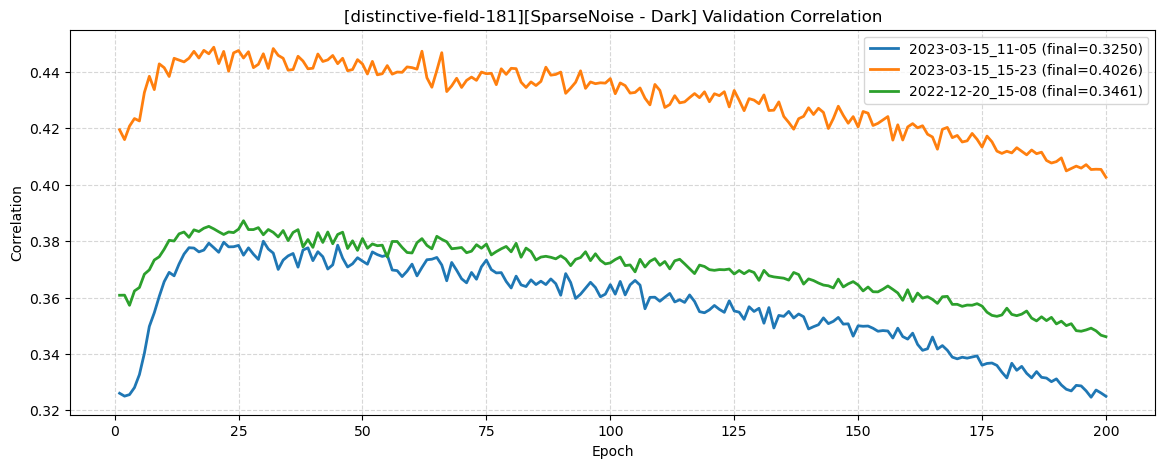

In [11]:
################ E. Main Plots ################
from neuropixel_predictor.utils import plot_metric

# plot_metric(history, 'training_loss', "[Moving Bar, Run 1] Training Loss", "Loss")
# plot_metric(history, 'val_loss', "[Moving Bar, Run 1] Validation Loss", "Loss")
plot_metric(history, 'val_corr', "[{}][SparseNoise - Dark] Validation Correlation".format(run.name), "Correlation")


## 7. Produce MEIs

### 7.1 One plot per neuron

In [ ]:
################ F. One Plot per neuron with stats ################

from neuropixel_predictor.utils import generate_reconstructed_data, calculate_corr_stats
from neuropixel_predictor.plotting import plot_all_methods_per_neuron
from neuropixel_predictor.mei.generate import generate_meis

UNIFIED_PLOT_DIR = os.path.join(ROOT_DIR, PLOTS_DIR, 'unified_plot')
MEIS_STEPS = 400
model.to(torch.device('mps'))

# 1. Load the clusters (to connect to unit IDs from experimental data)
cluster_ids_dir = "/Users/tarek/Documents/UNI/Lab Rotations/Kremkow/Data/Stimuli-Responses-Delay"
cluster_ids = {
    "2022-12-20_15-08": np.load(os.path.join(cluster_ids_dir, '2022-12-20_15-08_cluster_ids.npy')),
    "2023-03-15_11-05": np.load(os.path.join(cluster_ids_dir, '2023-03-15_11-05_cluster_ids.npy')),
    "2023-03-15_15-23": np.load(os.path.join(cluster_ids_dir, '2023-03-15_15-23_cluster_ids.npy'))
}

# 2. Calculate correlations (training and test)
test_corr = calculate_corr_stats(test_dataloaders, model)
training_corr = calculate_corr_stats(train_dataloaders, model)

# 3. Generate reconstructured data to plot timeseries
test_Y, test_Yhat, test_ids = generate_reconstructed_data(test_dataloaders, model)
training_Y, training_Yhat, training_ids = generate_reconstructed_data(train_dataloaders, model)

# 4. Generate the meis
n_neurons_dict = {
    '2023-03-15_11-05': 373, # old: 373
    # '2023-03-15_15-23': 196, # old: 388
    # '2022-12-20_15-08': 271  # old: 466
}

meis_tensors = generate_meis(model, n_neurons_dict, steps=MEIS_STEPS)

# reconstruction_metadata = {'st0': '2023-03-15_11-05_2_sn_dark', 'st1': '2023-03-15_11-05_3_sn_light'}
# run.name = 'SparseNoise-Light-1'

# 5. Plot all together
plot_all_methods_per_neuron(
    training_Y,
    training_Yhat,
    training_ids,
    test_Y,
    test_Yhat,
    test_ids,
    reconstruction_metadata,
    meis_tensors,
    meis_steps=MEIS_STEPS,
    run_name=run.name,
    cluster_ids=cluster_ids,
    training_neuron_stats=training_corr,
    test_neuron_stats=test_corr,
    save_dir=UNIFIED_PLOT_DIR
)

### 7.2 Optimization code for MEIs

In [ ]:
################################################################################################
#################### MEI CODE: This code shouldn't be here! ONLY FOR TESTING PURPOSES ####################
################################################################################################

import matplotlib.pyplot as plt
from neuropixel_predictor.mei.methods import MEIConfig
import torch.nn.functional as F
from dataclasses import dataclass

IMAGE_WIDTH = 36
IMAGE_HEIGHT = 22

SAVE_DIR = 'meis'

@dataclass
class MEIConfig:
    """Configuration for MEI optimization."""
    lr: float = 0.05
    steps: int = 300
    init_std: float = 0.5
    l2_lambda: float = 1e-3
    tv_lambda: float = 5e-4
    clip_min: float = -5.0
    clip_max: float = 5.0
    mode: str = "cei"   # "cei", "vei_plus", "vei_minus"

def total_variation(x):
    """Total variation regularizer."""
    tv_h = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    tv_w = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    return tv_h + tv_w


def gaussian_kernel2d(sigma, device="cpu", max_kernel_size=49):
    """
    Create a fixed-size 2D Gaussian kernel with sigma.
    Args:
        sigma: blur width
        max_kernel_size: odd integer (e.g., 49, 31)
    """
    # Ensure odd
    assert max_kernel_size % 2 == 1

    # Create coordinate grid
    ax = torch.arange(max_kernel_size, dtype=torch.float32, device=device) - (max_kernel_size - 1) / 2
    xx, yy = torch.meshgrid(ax, ax)
    
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2 + 1e-8))
    kernel = kernel / kernel.sum()

    return kernel

def blur_image(img, sigma, device='cpu'):
    """
    Blur `img` with a fixed-size Gaussian kernel.
    """
    B, C, W, H = img.shape
    kernel = gaussian_kernel2d(sigma, device=device, max_kernel_size=49)
    kernel = kernel.unsqueeze(0).unsqueeze(0)  # shape = (1,1,K,K)
    kernel = kernel.repeat(C, 1, 1, 1)

    # same padding
    padding = (kernel.shape[-1] // 2, kernel.shape[-2] // 2)

    out = F.conv2d(img, kernel, padding=padding, groups=C)
    return out

def blur_schedule(step, steps, sigma_start, sigma_end):
    """
    Linearly interpolate blur sigma:
      starts at sigma_start, ends at sigma_end
    """
    t = step / (steps - 1)
    return sigma_start * (1 - t) + sigma_end * t

class MEIMethod:
    def __init__(self, config: MEIConfig):
        self.config = config

    def loss(self, model, image, data_key, idx):
        """Define the objective depending on CEI / VEI±."""
        if self.config.mode == "cei":
            pred = model(image, data_key=data_key)[0, 0, idx]
            rate = torch.exp(pred)
            loss = -rate
            # loss = -pred

        elif self.config.mode == "vei_plus":
            pred_var = model.predict_variance(image, data_key=data_key)[0, 0, idx]
            loss = -pred_var

        elif self.config.mode == "vei_minus":
            pred_var = model.predict_variance(image, data_key=data_key)[0, 0, idx]
            loss = pred_var  # minimize variance

        else:
            raise ValueError(f"Unknown MEI mode: {self.config.mode}")

        # Regularizers
        l2_reg = self.config.l2_lambda * (image ** 2).mean()
        tv_reg = self.config.tv_lambda * total_variation(image)

        return loss + l2_reg + tv_reg

    def optimize(self, model, data_key, neuron_idx, image_shape, steps, device="cuda"):
        """Run gradient ascent to obtain MEI."""
        # Initialize input with Gaussian noise
        image = (
            torch.randn(image_shape, device=device) * self.config.init_std
        ).requires_grad_(True)

        optimizer = torch.optim.Adam([image], lr=self.config.lr)

        for step in range(steps):
            optimizer.zero_grad()

            loss = self.loss(model, image, data_key, neuron_idx)
            # print("loss: ", loss)
            loss.backward()

            # blur gradient before step
            # sigma = blur_schedule(step, steps, 4.0, 0.5)  # adjust
            # with torch.no_grad():
            #     image.grad.data = blur_image(image.grad.data, sigma, device=image.device)

            optimizer.step()
            # with torch.no_grad():
            #     norm = image.norm()
            #     target_norm = 10.0
            #     image.data = image.data / (norm + 1e-8) * target_norm
            
            # print(image.mean().item(), image.std().item())
            # Keep image in allowed range
            image.data.clamp_(self.config.clip_min, self.config.clip_max)

        return image.detach()


def generate_mei(model, data_key, neuron_idx, image_shape,
                 steps=300, mode="cei", device="cuda"):
    """
    High-level wrapper to generate a MEI.
    """
    config = MEIConfig(mode=mode)
    mei_method = MEIMethod(config)

    model.to(device)
    model.eval()

    # with torch.no_grad():
    #     # Optional: warmup or model-specific initialization
    #     pass

    mei = mei_method.optimize(model, data_key, neuron_idx, image_shape, steps=steps, device=device)
    return mei

def plot_mei(mei_tensor, neuron_idx, title="MEI", save_folder=None, ax=None):
    """
    mei_tensor: torch.Tensor with shape (1, C, H, W) or (C, H, W)
    """
    # Move to CPU and convert to numpy
    img = mei_tensor.detach().cpu().squeeze()

    img = torch.moveaxis(img, 1, 0) # Flip the axis to have (H, W)

    if ax:
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
    else:
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")

    if save_folder:
        filename = f"mei_neuron{neuron_idx:03d}.png"
        filepath = os.path.join(save_folder, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.show()
        # plt.close(fig)

def generate_and_save_meis(model, n_neurons_dict, steps=600, folder_suffix=None, cluster_ids=None, title_suffix=""):
    date = datetime.now().strftime("%Y-%m-%d")

    sub_dir = f"{date}_({folder_suffix})" if folder_suffix else date
    os.makedirs(SAVE_DIR, exist_ok=True)

    image_shape = (1, 1, IMAGE_WIDTH, IMAGE_HEIGHT)
    
    total_meis = sum(n_neurons_dict.values())
    current_mei = 0

    device = "cuda" if torch.cuda.is_available() else "mps"
    
    print(f"Generating {total_meis} MEIs across {len(n_neurons_dict.keys())} data keys...")
    
    for data_key in n_neurons_dict.keys():
        num_neurons = n_neurons_dict[data_key]
        
        # Create required directories
        key_save_dir = os.path.join(SAVE_DIR, sub_dir, data_key)
        os.makedirs(key_save_dir, exist_ok=True)

        print(f"\nProcessing data_key: {data_key} ({num_neurons} neurons)")
        for neuron_idx in range(num_neurons):
            current_mei += 1

            # Generate MEI
            mei = generate_mei(
                model,
                data_key,
                neuron_idx,
                image_shape,
                steps=steps,
                mode='cei',
                device=device
            )
            # Create figure and plot
            fig, ax = plt.subplots(figsize=(8, 6))

            cluster = f"{neuron_idx} (#{cluster_ids[data_key][neuron_idx]})" if cluster_ids else neuron_idx
            plot_mei(
                mei,
                neuron_idx,
                title=f"MEI - {data_key}, Neuron: {cluster}, Steps: {steps} {title_suffix}",
                save_folder=key_save_dir
            )

In [ ]:
from datetime import datetime

# ################ E. Generate MEIs ################
n_neurons_dict = {
    '2023-03-15_11-05': 260,
    # '2023-03-15_15-23': 268,
    # '2022-12-20_15-08': 327
}


model.to(torch.device('mps'))

date = datetime.now().strftime("%Y-%m-%d")
generate_and_save_meis(model, n_neurons_dict, steps=400, folder_suffix= run.name, cluster_ids=cluster_ids, title_suffix="")

## 8. Visualization of core features

### 8.1 Visualization of current model core features

In [ ]:
# get first conv layer weights
w = model.core.features[0][0].weight.data.cpu()
print(w.shape)

num_filters = min(32, w.shape[0])

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i >= num_filters:
        break

    filt = w[i, 0]  # first input channel

    ax.imshow(filt, cmap='gray')
    ax.axis('off')
    ax.set_title(str(i))

plt.suptitle("Core Features - Newer Model (likely-frog-168)")
plt.tight_layout()
plt.show()


### 8.2 Visualization of previous model core features to compare

In [ ]:
# import wandb

api = wandb.Api()
run = api.run("charite-ahmedtarek-/np-predictor/n364nbp7")

model_prev = initialize_model(run)

run = wandb.init()
artifact = run.use_artifact('charite-ahmedtarek-/np-predictor/np-predictor:v11', type='model')
artifact_dir = artifact.download()

model_load_path = os.path.join(artifact_dir, 'first_full_model.pt')
model_state_dict = torch.load(model_load_path, map_location="cpu", weights_only=False)
model_prev.load_state_dict(model_state_dict, strict=False)
model_prev.to(torch.device('mps'))


w = model_prev.core.features[0][0].weight.data.cpu()
print(w.shape)

num_filters = min(32, w.shape[0])

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i >= num_filters:
        break

    filt = w[i, 0]  # first input channel

    ax.imshow(filt, cmap='gray')
    ax.axis('off')
    ax.set_title(str(i))

plt.suptitle("Core Features - Older Model (SparseNoise-Dark-1)")
plt.tight_layout()
plt.show()


### 8.3 Visualization of spatial masks (new vs old)

In [ ]:
spatial_new = model.readout['2023-03-15_11-05'].spatial.data.cpu()
spatial_old = model_prev.readout['2023-03-15_11-05'].spatial.data.cpu()

neuron = 16

mask_new = spatial_new[neuron, :, :]
mask_old = spatial_old[neuron, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mask_old, cmap='gray')
axes[0].set_title("[OLD] Readout spatial mask")

axes[1].imshow(mask_new, cmap='gray')
axes[1].set_title("[NEW] Readout spatial mask")

# fig.colorbar()/
plt.show()